# Behavioral Authentication Defender Pipeline on Balabit

This notebook evaluates behavioral (mouse-movement) authentication against real synthetic attacks. Defender models are trained and calibrated per user, then tested against real attacker-generated sessions (WindMouse and SapiAgent, both scored across all four defender tiers), with a vulnerability classifier, anomaly detection layer, and threshold-floor correction all backed by real attack data rather than placeholders.

**Evaluation design:**

Binary authentication: 1 = genuine enrolled user, 0 = imposter

Per-user models: each user is evaluated separately

Window size: 128 time steps

Fair protocol: same users, windows, fit/calibration/test split, seeds, threshold policies, and metrics across tiers

Threshold policies: default 0.5, calibration EER threshold, calibration low-FAR threshold, and a floored low-FAR threshold (prevents the threshold from collapsing to near-zero)

**Model tiers:**

*   T0: rule/threshold sanity baseline
*   T1: Logistic Regression, SVM, k-NN, and Decision Tree
*   T2: Random Forest, ExtraTrees, Gradient Boosting, and XGBoost
*   T3: 1D-CNN sequence baseline

**Reported metrics** include TAR, FAR, FRR, F1, AUC, EER, and per-user vulnerability.

**Key components:**
- **Threshold floor policy** - fixes a reproducible calibration failure (one user's CNN defender collapsed to a near-zero threshold across all 3 seeds despite perfect clean AUC) without affecting any other user/model combination.
- **Vulnerability classifier** - predicts bypass risk (bypassed at all vs. never) using real bypass rate as the target label, with a proper leave-one-user-out evaluation, confusion matrix, and feature importance.
- **Anomaly detection layer** - tested against real SapiAgent and WindMouse attack sessions instead of just human imposters, with a direct catch-rate comparison across attackers.
- **Robustness drop** - direct comparison of clean FAR vs. real attack bypass rate. Headline finding: clean FAR does not predict robustness - several models with excellent clean FAR were completely bypassed by SapiAgent.
- **WindMouse and SapiAgent both scored across all four tiers**, enabling a direct, like-for-like comparison between attackers - see the Attacker Comparison section near the end.

---

**Handoff note for whoever runs this next:** the Drive paths in this notebook (e.g. `/content/drive/MyDrive/handoff/...`) point to whichever Google account is mounted in *your* Colab session. If you are running this in a different account than whoever built it, either upload the same session files (`sapiagent_sessions`, `windmouse_sessions`, etc.) to your own Drive at the same path, or update the paths together before running.


# Revision notes for the final REU analysis

This revision preserves the original project structure but corrects several issues that materially affect the paper-level conclusions.

## Required changes implemented here

1. **Session-level data separation.** Fit, calibration, CNN validation, and test sets are separated by complete sessions. Windows from the same session can no longer appear in both model fitting and threshold calibration.
2. **Duplicate-timestamp preprocessing.** Consecutive records sharing a timestamp are collapsed before computing velocity, acceleration, jerk, and curvature. The previous `dt = 1e-6` replacement created clipped artificial motion for many tied timestamps.
3. **Session-level statistics.** Seeds are treated as repeated fits for the same user—not as independent participants. Central comparisons use user-level aggregation, bootstrap intervals, or paired permutation tests.
4. **Threshold-floor interpretation.** The floor is retained only as a sensitivity analysis. A universal raw-score floor is not directly comparable across SVMs, trees, ensembles, and neural networks.
5. **Corrected anomaly evaluation.** The layered defense now counts complete sessions, runs across all users and seeds, includes all three attackers, avoids triplicating genuine rows, and calibrates the anomaly threshold on held-out genuine sessions.
6. **Mechanism analysis.** A new section tests whether attacker bypass is associated with target proximity and distance from the pooled-negative manifold.
7. **Vulnerability classifier.** Random row-level cross-validation is removed. Leave-one-user-out evaluation is reported against balanced-accuracy and PR-AUC baselines, with sensitivity to the definition of “vulnerable.”

**Important:** outputs from the original notebook were cleared because the preprocessing and splitting corrections change the fitted models and all downstream results. Rerun the notebook from the beginning before copying any number into the paper or poster.

#Setting Up the Environment

In [20]:
# Mounts your Google Drive so files can be read/saved from /content/drive/MyDrive/.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Audit Setup: Project & Output Directories

In [21]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/ABAST_REU")
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Output directory:", OUTPUT_DIR)


Project directory: /content/drive/MyDrive/ABAST_REU
Output directory: /content/drive/MyDrive/ABAST_REU/outputs


In [22]:
# Sets random seeds for TensorFlow/NumPy/Python for reproducibility across runs.
import tensorflow as tf, numpy as np, random;
#print(tf.__version__)
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Get the Data

In [23]:
!git clone https://github.com/balabit/Mouse-Dynamics-Challenge

fatal: destination path 'Mouse-Dynamics-Challenge' already exists and is not an empty directory.


# Loading the Data

In [24]:
# Defines load_session(): reads one raw Balabit session CSV and standardizes its columns.
#
# kind="stable" is REQUIRED, not cosmetic. 46% of Balabit records share a timestamp with
# an adjacent record (event-driven RDP logging quantizes time), and pandas' default
# quicksort is UNSTABLE, so the order of tied rows depends on the library build. That
# changes dx/dy, which changes every extracted feature and every calibrated threshold
# downstream. Verified on user9/seed0 T0 (a deterministic centroid-distance score with no
# RNG): 0.6532 under one tie ordering, 0.6509 under another, 0.5978 under stable sort.
# Stable sort keeps ties in file order, which is defined and version-independent.
import pandas as pd

def load_session(path):
    df = pd.read_csv(path, sep=',')
    df = df.sort_values('record timestamp', kind='stable')
    df = df.dropna(subset=['x', 'y'])
    return df

In [25]:
# Loads all training sessions into `all_sessions` (list of dataframes, one per session).
import os

all_sessions = []

training_path = '/content/Mouse-Dynamics-Challenge/training_files'

for user in sorted(os.listdir(training_path)):
    user_path = os.path.join(training_path, user)
    if not os.path.isdir(user_path):
        continue
    for session_file in sorted(os.listdir(user_path)):
        session_path = os.path.join(user_path, session_file)
        df = load_session(session_path)
        df['user'] = user
        df['session'] = session_file
        df['label'] = 0
        all_sessions.append(df)

print(f"Loaded {len(all_sessions)} sessions")

Loaded 65 sessions


In [26]:
# Check which users loaded and how many sessions each has
from collections import Counter
user_counts = Counter(df['user'].iloc[0] for df in all_sessions)
print(user_counts)

Counter({'user12': 7, 'user20': 7, 'user21': 7, 'user29': 7, 'user7': 7, 'user9': 7, 'user15': 6, 'user16': 6, 'user23': 6, 'user35': 5})


In [27]:
# Loads the public test-set labels (genuine/imposter) for the Balabit test sessions.
import pandas as pd

# Load labels
labels_path = '/content/Mouse-Dynamics-Challenge/public_labels.csv'
labels_df = pd.read_csv(labels_path, sep=',')
print(labels_df.head())
print(labels_df.shape)

             filename  is_illegal
0  session_0003960194           1
1  session_0005840196           0
2  session_0025450757           0
3  session_0029922803           0
4  session_0064281061           1
(816, 2)


In [28]:
# Loads all test sessions into `test_sessions`, matched against the labels above.
test_sessions = []

test_path = '/content/Mouse-Dynamics-Challenge/test_files'

for user in sorted(os.listdir(test_path)):
    user_path = os.path.join(test_path, user)
    if not os.path.isdir(user_path):
        continue
    for session_file in sorted(os.listdir(user_path)):
        session_path = os.path.join(user_path, session_file)

        # look up label from public_labels.csv
        match = labels_df[labels_df['filename'] == session_file]
        if match.empty:
            continue  # skip sessions without a public label

        label = match.iloc[0]['is_illegal']
        df = load_session(session_path)
        df['user'] = user
        df['session'] = session_file
        df['label'] = label
        test_sessions.append(df)

print(f"Loaded {len(test_sessions)} labeled test sessions")

# sanity check label distribution
import collections
label_counts = collections.Counter(df['label'].iloc[0] for df in test_sessions)
print(label_counts)

Loaded 816 labeled test sessions
Counter({np.int64(0): 411, np.int64(1): 405})


# Feature Extraction

In [29]:
# Feature extraction with explicit treatment of quantized/tied timestamps.

def collapse_duplicate_timestamps(df):
    """
    Collapse records sharing a timestamp to the last observed pointer position.

    Balabit timestamps are quantized, so replacing zero time differences by an
    extremely small epsilon creates artificial velocities, accelerations, and
    jerk. Stable sorting preserves file order before duplicate timestamps are
    collapsed.
    """
    required = ["record timestamp", "x", "y"]
    missing = set(required) - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    core = (
        df[required]
        .sort_values("record timestamp", kind="stable")
        .dropna(subset=["record timestamp", "x", "y"])
        .groupby("record timestamp", as_index=False, sort=False)
        .agg({"x": "last", "y": "last"})
    )
    return core


def extract_features(df):
    core = collapse_duplicate_timestamps(df).reset_index(drop=True)

    if len(core) < 2:
        return pd.DataFrame(columns=[
            "dt", "step_distance", "vx", "vy", "velocity",
            "acceleration", "jerk", "angle", "curvature", "pause",
        ])

    dt = core["record timestamp"].diff()
    positive_dt = dt[dt > 0]
    fallback_dt = float(positive_dt.median()) if len(positive_dt) else 1.0
    dt = dt.fillna(fallback_dt)
    dt = dt.where(dt > 0, fallback_dt)

    dx = core["x"].diff().fillna(0.0)
    dy = core["y"].diff().fillna(0.0)
    step_distance = np.hypot(dx, dy)

    vx = dx / dt
    vy = dy / dt
    velocity = step_distance / dt
    acceleration = velocity.diff().fillna(0.0) / dt
    jerk = acceleration.diff().fillna(0.0) / dt

    angle = np.arctan2(dy, dx)
    raw_angle_change = angle.diff().fillna(0.0)
    wrapped_angle_change = np.angle(np.exp(1j * raw_angle_change))
    curvature = wrapped_angle_change / step_distance.replace(0, np.nan)

    pause = (dt > 0.10).astype(int)

    result = pd.DataFrame({
        "dt": dt,
        "step_distance": step_distance,
        "vx": vx,
        "vy": vy,
        "velocity": velocity,
        "acceleration": acceleration,
        "jerk": jerk,
        "angle": angle,
        "curvature": curvature,
        "pause": pause,
    })

    result = result.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Generous caps remain only as numerical safeguards. Report a sensitivity
    # analysis if conclusions depend on these limits.
    result["vx"] = result["vx"].clip(-5000, 5000)
    result["vy"] = result["vy"].clip(-5000, 5000)
    result["velocity"] = result["velocity"].clip(0, 5000)
    result["acceleration"] = result["acceleration"].clip(-1e6, 1e6)
    result["jerk"] = result["jerk"].clip(-1e8, 1e8)
    result["curvature"] = result["curvature"].clip(-100, 100)

    return result


sample = extract_features(all_sessions[0])
print(sample.describe())

                 dt  step_distance            vx            vy      velocity  \
count  25654.000000   25654.000000  25654.000000  25654.000000  25654.000000   
mean       0.610237      62.679253    -14.167265     -9.796793    470.899834   
std        8.684458     821.260038    967.147147    864.648976    987.139693   
min        0.001000       0.000000  -5000.000000  -5000.000000      0.000000   
25%        0.111000       2.828427    -58.413004    -38.149775     11.840068   
50%        0.120000      14.000000      0.000000      0.000000    102.213113   
75%        0.216000      51.324924     35.714289     26.785714    424.918572   
max      686.372000   91793.558478   5000.000000   5000.000000   5000.000000   

         acceleration          jerk         angle     curvature         pause  
count    25654.000000  2.565400e+04  25654.000000  25654.000000  25654.000000  
mean     16480.147733  5.504079e+05      0.109172      0.036082      0.921455  
std     182774.063717  2.171704e+07    

# Audit: Timestamp Preprocessing

Checks the duplicate-timestamp fix produced finite, sane velocity/acceleration/jerk values.

In [30]:
def timestamp_audit(session_list):
    rows = []
    for index, session in enumerate(session_list):
        timestamps = session["record timestamp"]
        duplicate_rate = float(timestamps.duplicated(keep=False).mean())
        collapsed = collapse_duplicate_timestamps(session)
        features = extract_features(session)
        rows.append({
            "session_index": index,
            "user": session["user"].iloc[0],
            "session": session["session"].iloc[0],
            "raw_rows": len(session),
            "collapsed_rows": len(collapsed),
            "duplicate_timestamp_rate": duplicate_rate,
            "velocity_p99": features["velocity"].quantile(0.99),
            "acceleration_p99_abs": features["acceleration"].abs().quantile(0.99),
            "jerk_p99_abs": features["jerk"].abs().quantile(0.99),
        })
    return pd.DataFrame(rows)

timestamp_report = timestamp_audit(all_sessions)
display(timestamp_report.describe(include="all"))
display(timestamp_report.sort_values("duplicate_timestamp_rate", ascending=False).head(10))
timestamp_report.to_csv(OUTPUT_DIR / "timestamp_preprocessing_audit.csv", index=False)


,session_index,user,session,raw_rows,collapsed_rows,duplicate_timestamp_rate,velocity_p99,acceleration_p99_abs,jerk_p99_abs
count,65.00000,65,65,65.000000,65.000000,65.000000,65.0,65.000000,65.0
unique,NaN,10,65,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,user12,session_2144641057,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,7,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,32.00000,NaN,NaN,34674.092308,18677.015385,0.501742,5000.0,990921.250511,100000000.0
std,18.90767,NaN,NaN,17656.345618,9015.090501,0.302111,0.0,73195.218411,0.0
min,0.00000,NaN,NaN,13640.000000,7434.000000,0.208384,5000.0,409881.283227,100000000.0
25%,16.00000,NaN,NaN,18119.000000,12634.000000,0.277150,5000.0,1000000.000000,100000000.0
50%,32.00000,NaN,NaN,31441.000000,16147.000000,0.316349,5000.0,1000000.000000,100000000.0
75%,48.00000,NaN,NaN,48209.000000,23785.000000,0.914566,5000.0,1000000.000000,100000000.0


,session_index,user,session,raw_rows,collapsed_rows,duplicate_timestamp_rate,velocity_p99,acceleration_p99_abs,jerk_p99_abs
62,62,user9,session_5155383252,59781,8886,0.959803,5000.0,1000000.0,100000000.0
64,64,user9,session_8764610836,56517,8771,0.957128,5000.0,1000000.0,100000000.0
58,58,user9,session_0335985747,54418,8423,0.957018,5000.0,1000000.0,100000000.0
21,21,user20,session_2372891077,60087,11821,0.953651,5000.0,1000000.0,100000000.0
25,25,user20,session_9818121880,39131,7970,0.952033,5000.0,1000000.0,100000000.0
59,59,user9,session_3390119815,58141,9375,0.951532,5000.0,1000000.0,100000000.0
61,61,user9,session_4373781904,56973,9159,0.949239,5000.0,1000000.0,100000000.0
60,60,user9,session_3879637058,72732,12148,0.946956,5000.0,1000000.0,100000000.0
23,23,user20,session_7888368102,31441,7434,0.944436,5000.0,1000000.0,100000000.0
19,19,user20,session_0214655159,36004,8667,0.941812,5000.0,1000000.0,100000000.0


# Windowing, labels, and the splie

In [31]:
# Fixed-length windows. The fair evaluation below performs all splits by
# complete session before this function is called.
WINDOW = 128
FEATURE_COLS = [
    "dt", "step_distance", "vx", "vy", "velocity",
    "acceleration", "jerk", "angle", "curvature", "pause",
]


def session_identifier(df, fallback="unknown_session"):
    user = str(df["user"].iloc[0]) if "user" in df.columns and len(df) else "unknown_user"
    session = str(df["session"].iloc[0]) if "session" in df.columns and len(df) else fallback
    return f"{user}:{session}"


def make_windows(session_list):
    X, y, groups = [], [], []
    for position, df in enumerate(session_list):
        features = extract_features(df)[FEATURE_COLS].to_numpy(dtype=float)
        label = int(df["label"].iloc[0])
        group = session_identifier(df, fallback=f"session_{position}")
        n_windows = len(features) // WINDOW

        for window_index in range(n_windows):
            start = window_index * WINDOW
            X.append(features[start:start + WINDOW])
            y.append(label)
            groups.append(group)

    return (
        np.asarray(X, dtype=float),
        np.asarray(y, dtype=int),
        np.asarray(groups, dtype=object),
    )


X_smoke, y_smoke, group_smoke = make_windows(all_sessions[:3])
print("Smoke-test windows:", X_smoke.shape)
print("Distinct source sessions:", len(np.unique(group_smoke)))

Smoke-test windows: (753, 128, 10)
Distinct source sessions: 3


# Fair T0-T3 Baseline Comparison

The models have different complexity by design, but the evaluation protocol is held constant. T3 uses an internal validation split for early stopping so the calibration split remains reserved for threshold selection, matching the role of calibration data in T0/T1/T2.


In [32]:
# Core evaluation helpers.
from IPython.display import display
import random as pyrandom
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

FAIR_SEEDS = [0, 1, 2]
CALIBRATION_SIZE = 0.25
T3_VALIDATION_SIZE = 0.20
LOW_FAR_TARGET = 0.10
THRESHOLD_FLOOR = 0.05
T3_EPOCHS = 20
T3_BATCH_SIZE = 64
summary_cols = ["TAR", "FAR", "FRR", "F1", "AUC", "EER"]


def windows_from_sessions(session_list, label, return_groups=False):
    X, groups = [], []
    for position, df in enumerate(session_list):
        features = extract_features(df)[FEATURE_COLS].to_numpy(dtype=float)
        group = session_identifier(df, fallback=f"session_{position}")
        n_windows = len(features) // WINDOW

        for window_index in range(n_windows):
            start = window_index * WINDOW
            X.append(features[start:start + WINDOW])
            groups.append(group)

    X = np.asarray(X, dtype=float)
    y = np.full(len(X), int(label), dtype=int)
    groups = np.asarray(groups, dtype=object)

    if return_groups:
        return X, y, groups
    return X, y


def get_user(df):
    return df["user"].iloc[0]


def get_label(df):
    return df["label"].iloc[0]


def summarize_window(window):
    window = np.asarray(window, dtype=float)
    row = {}

    for column_index, name in enumerate(FEATURE_COLS):
        values = window[:, column_index]
        values = values[np.isfinite(values)]
        if len(values) == 0:
            values = np.array([0.0])

        row[f"{name}_mean"] = float(np.mean(values))
        row[f"{name}_std"] = float(np.std(values))
        row[f"{name}_median"] = float(np.median(values))
        row[f"{name}_min"] = float(np.min(values))
        row[f"{name}_max"] = float(np.max(values))
        row[f"{name}_p25"] = float(np.percentile(values, 25))
        row[f"{name}_p75"] = float(np.percentile(values, 75))
        row[f"{name}_p90"] = float(np.percentile(values, 90))

    distance_index = FEATURE_COLS.index("step_distance")
    dt_index = FEATURE_COLS.index("dt")
    pause_index = FEATURE_COLS.index("pause")

    row["path_length"] = float(np.sum(np.maximum(window[:, distance_index], 0)))
    row["duration_seconds"] = float(np.sum(np.maximum(window[:, dt_index], 0)))
    row["pause_rate"] = float(np.mean(window[:, pause_index] > 0))
    row["n_events"] = int(window.shape[0])
    return row


def windows_to_tabular(X_windows):
    rows = [summarize_window(window) for window in X_windows]
    return (
        pd.DataFrame(rows)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )


def compute_eer_threshold(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return np.nan, 0.5

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr
    index = np.nanargmin(np.abs(fpr - fnr))
    return (
        float((fpr[index] + fnr[index]) / 2),
        float(thresholds[index]),
    )


def threshold_for_target_far(
    y_true,
    scores,
    target_far=LOW_FAR_TARGET,
):
    """
    Select the lowest calibration threshold attaining the maximum TAR while
    satisfying the requested FAR. Scores and labels must come only from a
    held-out calibration set.
    """
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    candidates = np.r_[np.unique(scores), np.nextafter(scores.max(), np.inf)]

    best_threshold = float(candidates.max())
    best_tar = -1.0
    best_far = 0.0

    for threshold in np.sort(candidates):
        prediction = (scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            prediction,
            labels=[0, 1],
        ).ravel()

        tar = tp / (tp + fn) if (tp + fn) else 0.0
        far = fp / (fp + tn) if (fp + tn) else 0.0

        if far <= target_far and tar > best_tar:
            best_threshold = float(threshold)
            best_tar = float(tar)
            best_far = float(far)

    return best_threshold, best_far, best_tar


def evaluate_auth_scores(y_true, scores, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    prediction = (scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1],
    ).ravel()

    tar = tp / (tp + fn) if (tp + fn) else 0.0
    far = fp / (fp + tn) if (fp + tn) else 0.0
    frr = fn / (tp + fn) if (tp + fn) else 0.0
    auc = (
        roc_auc_score(y_true, scores)
        if len(np.unique(y_true)) > 1
        else np.nan
    )
    eer, eer_threshold = compute_eer_threshold(y_true, scores)

    return {
        "TAR": tar,
        "FAR": far,
        "FRR": frr,
        "F1": f1_score(y_true, prediction, zero_division=0),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "AUC": auc,
        "EER": eer,
        "test_EER_threshold": eer_threshold,
        "decision_threshold": float(threshold),
    }


def threshold_policy_rows(
    user,
    tier,
    model_name,
    y_cal,
    cal_scores,
    y_test,
    test_scores,
    seed,
):
    cal_eer, cal_eer_threshold = compute_eer_threshold(y_cal, cal_scores)
    low_far_threshold, cal_far, cal_tar = threshold_for_target_far(
        y_cal,
        cal_scores,
        target_far=LOW_FAR_TARGET,
    )

    # The absolute floor is retained as a sensitivity policy only. Raw score
    # scales are not directly comparable across model families.
    floored_threshold = max(low_far_threshold, THRESHOLD_FLOOR)

    policies = [
        ("default_0.5", 0.5, np.nan, np.nan, np.nan),
        ("calibration_EER", cal_eer_threshold, cal_eer, np.nan, np.nan),
        (
            f"calibration_FAR<={LOW_FAR_TARGET:.2f}",
            low_far_threshold,
            np.nan,
            cal_far,
            cal_tar,
        ),
        (
            f"calibration_FAR<={LOW_FAR_TARGET:.2f}_floor_{THRESHOLD_FLOOR:.2f}",
            floored_threshold,
            np.nan,
            cal_far,
            cal_tar,
        ),
    ]

    rows = []
    for policy_name, threshold, cal_eer_value, cal_far_value, cal_tar_value in policies:
        metrics = evaluate_auth_scores(
            y_test,
            test_scores,
            threshold=threshold,
        )
        metrics.update({
            "user": user,
            "tier": tier,
            "model": model_name,
            "threshold_policy": policy_name,
            "calibration_EER": cal_eer_value,
            "calibration_FAR_at_threshold": cal_far_value,
            "calibration_TAR_at_threshold": cal_tar_value,
            "seed": seed,
        })
        rows.append(metrics)

    return rows

## Shared Per-User Split

Every tier uses this same split function. Training imposters are sampled from other users, then the training set is split into fit and calibration subsets.


In [33]:
# Session-level fit/calibration/test separation.
IMPOSTER_SESSION_RATIO = 3


def split_session_list(sessions, holdout_fraction, seed):
    sessions = list(sessions)
    if len(sessions) < 2:
        raise ValueError(
            "At least two sessions per class are required for a separate "
            "fit and calibration partition."
        )

    local_rng = np.random.default_rng(seed)
    order = local_rng.permutation(len(sessions))
    n_holdout = int(round(len(sessions) * holdout_fraction))
    n_holdout = min(max(n_holdout, 1), len(sessions) - 1)

    holdout_indices = set(order[:n_holdout].tolist())
    fit = [
        session for index, session in enumerate(sessions)
        if index not in holdout_indices
    ]
    holdout = [
        session for index, session in enumerate(sessions)
        if index in holdout_indices
    ]
    return fit, holdout


def combine_window_parts(parts, seed):
    X = np.concatenate([part[0] for part in parts], axis=0)
    y = np.concatenate([part[1] for part in parts], axis=0)
    groups = np.concatenate([part[2] for part in parts], axis=0)

    local_rng = np.random.default_rng(seed)
    order = local_rng.permutation(len(y))
    return X[order], y[order], groups[order]


def grouped_train_validation_indices(
    groups,
    labels,
    validation_fraction,
    seed,
):
    """
    Split complete sessions inside the CNN fitting partition. No session can
    contribute windows to both CNN training and early-stopping validation.
    """
    groups = np.asarray(groups)
    labels = np.asarray(labels).astype(int)

    group_table = (
        pd.DataFrame({"group": groups, "label": labels})
        .drop_duplicates("group")
    )

    train_groups, validation_groups = [], []
    for label_value in sorted(group_table["label"].unique()):
        label_groups = group_table.loc[
            group_table["label"] == label_value,
            "group",
        ].tolist()

        fit_groups, val_groups = split_session_list(
            label_groups,
            holdout_fraction=validation_fraction,
            seed=seed + 1000 * int(label_value),
        )
        train_groups.extend(fit_groups)
        validation_groups.extend(val_groups)

    train_index = np.flatnonzero(np.isin(groups, train_groups))
    validation_index = np.flatnonzero(np.isin(groups, validation_groups))
    return train_index, validation_index


def get_fair_user_splits(target, seed=42, balance_imposters=True):
    local_rng = np.random.default_rng(seed)

    genuine_train_sessions = [
        session for session in all_sessions
        if get_user(session) == target
    ]
    imposter_train_sessions = [
        session for session in all_sessions
        if get_user(session) != target
    ]

    if balance_imposters:
        desired_imposters = min(
            len(imposter_train_sessions),
            max(
                len(genuine_train_sessions),
                IMPOSTER_SESSION_RATIO * len(genuine_train_sessions),
            ),
        )
        selected = local_rng.choice(
            len(imposter_train_sessions),
            size=desired_imposters,
            replace=False,
        )
        imposter_train_sessions = [
            imposter_train_sessions[index]
            for index in selected
        ]

    fit_genuine, cal_genuine = split_session_list(
        genuine_train_sessions,
        CALIBRATION_SIZE,
        seed,
    )
    fit_imposter, cal_imposter = split_session_list(
        imposter_train_sessions,
        CALIBRATION_SIZE,
        seed + 17,
    )

    fit_parts = [
        windows_from_sessions(fit_genuine, 1, return_groups=True),
        windows_from_sessions(fit_imposter, 0, return_groups=True),
    ]
    cal_parts = [
        windows_from_sessions(cal_genuine, 1, return_groups=True),
        windows_from_sessions(cal_imposter, 0, return_groups=True),
    ]

    X_fit_seq, y_fit, groups_fit = combine_window_parts(
        fit_parts,
        seed,
    )
    X_cal_seq, y_cal, groups_cal = combine_window_parts(
        cal_parts,
        seed + 1,
    )

    genuine_test_sessions = [
        session for session in test_sessions
        if get_user(session) == target and get_label(session) == 0
    ]
    imposter_test_sessions = [
        session for session in test_sessions
        if get_user(session) == target and get_label(session) == 1
    ]

    test_parts = [
        windows_from_sessions(
            genuine_test_sessions,
            1,
            return_groups=True,
        ),
        windows_from_sessions(
            imposter_test_sessions,
            0,
            return_groups=True,
        ),
    ]
    X_test_seq, y_test, groups_test = combine_window_parts(
        test_parts,
        seed + 2,
    )

    X_fit_tab = windows_to_tabular(X_fit_seq)
    X_cal_tab = windows_to_tabular(X_cal_seq)
    X_test_tab = windows_to_tabular(X_test_seq)

    return {
        "X_fit_seq": X_fit_seq,
        "X_cal_seq": X_cal_seq,
        "X_test_seq": X_test_seq,
        "X_fit_tab": X_fit_tab.reset_index(drop=True),
        "X_cal_tab": X_cal_tab.reset_index(drop=True),
        "X_test_tab": X_test_tab.reset_index(drop=True),
        "y_fit": y_fit,
        "y_cal": y_cal,
        "y_test": y_test,
        "groups_fit": groups_fit,
        "groups_cal": groups_cal,
        "groups_test": groups_test,
        "fit_genuine_sessions": fit_genuine,
        "fit_imposter_sessions": fit_imposter,
        "cal_genuine_sessions": cal_genuine,
        "cal_imposter_sessions": cal_imposter,
        "test_genuine_sessions": genuine_test_sessions,
        "test_imposter_sessions": imposter_test_sessions,
    }

# Audit: Session-Split Leakage

Run before any model training below. If this fails, do not continue.

In [34]:
def split_leakage_audit(users, seeds):
    rows = []
    for user in users:
        for seed in seeds:
            splits = get_fair_user_splits(user, seed=seed)
            fit_groups = set(splits["groups_fit"])
            calibration_groups = set(splits["groups_cal"])
            test_groups = set(splits["groups_test"])
            cnn_train_index, cnn_validation_index = grouped_train_validation_indices(
                splits["groups_fit"], splits["y_fit"],
                validation_fraction=T3_VALIDATION_SIZE, seed=seed,
            )
            cnn_train_groups = set(splits["groups_fit"][cnn_train_index])
            cnn_validation_groups = set(splits["groups_fit"][cnn_validation_index])
            rows.append({
                "user": user, "seed": seed,
                "fit_calibration_overlap": len(fit_groups & calibration_groups),
                "fit_test_overlap": len(fit_groups & test_groups),
                "calibration_test_overlap": len(calibration_groups & test_groups),
                "cnn_train_validation_overlap": len(cnn_train_groups & cnn_validation_groups),
                "fit_sessions": len(fit_groups),
                "calibration_sessions": len(calibration_groups),
                "test_sessions": len(test_groups),
            })
    return pd.DataFrame(rows)

split_audit = split_leakage_audit(sorted(user_counts.keys()), FAIR_SEEDS)
display(split_audit)

overlap_columns = ["fit_calibration_overlap", "fit_test_overlap", "calibration_test_overlap", "cnn_train_validation_overlap"]
assert (split_audit[overlap_columns] == 0).all().all(), "Session leakage remains. Do not continue until all overlaps are zero."

split_audit.to_csv(OUTPUT_DIR / "session_split_audit.csv", index=False)
print("PASS: no session overlap detected.")


,user,seed,fit_calibration_overlap,fit_test_overlap,calibration_test_overlap,cnn_train_validation_overlap,fit_sessions,calibration_sessions,test_sessions
0,user12,0,0,0,0,0,21,7,105
1,user12,1,0,0,0,0,21,7,105
2,user12,2,0,0,0,0,21,7,105
3,user15,0,0,0,0,0,18,6,115
4,user15,1,0,0,0,0,18,6,115
5,user15,2,0,0,0,0,18,6,115
6,user16,0,0,0,0,0,18,6,106
7,user16,1,0,0,0,0,18,6,106
8,user16,2,0,0,0,0,18,6,106
9,user20,0,0,0,0,0,21,7,49


PASS: no session overlap detected.


# T0 Rule/Threshold Baseline


In [35]:
# T0 baseline: distance-to-genuine-centroid scoring, no training beyond computing the centroid.
def t0_distance_profile_scores(X_fit, y_fit, X_eval):
    scaler = StandardScaler().fit(X_fit)
    X_fit_s = scaler.transform(X_fit)
    X_eval_s = scaler.transform(X_eval)
    center = np.median(X_fit_s[y_fit == 1], axis=0)
    distance = np.sqrt(np.mean((X_eval_s - center) ** 2, axis=1))
    return 1.0 / (1.0 + distance)


def run_user_t0_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    cal_scores = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    test_scores = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_test_tab"])
    return pd.DataFrame(threshold_policy_rows(user, "T0", "T0_DistanceProfile", splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))

example_user = sorted(user_counts.keys())[0]
run_user_t0_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T0,T0_DistanceProfile,default_0.5,0.500000,0.792453,0.675497,0.207547,0.713881,0.644002,0.391381
1,user12,T0,T0_DistanceProfile,calibration_EER,0.557197,0.664570,0.470199,0.335430,0.677350,0.644002,0.391381
2,user12,T0,T0_DistanceProfile,calibration_FAR<=0.10,0.627379,0.327044,0.145695,0.672956,0.460857,0.644002,0.391381
3,user12,T0,T0_DistanceProfile,calibration_FAR<=0.10_floor_0.05,0.627379,0.327044,0.145695,0.672956,0.460857,0.644002,0.391381


# T1 Classical Baselines


In [36]:
# build_t1_models(): LogReg, SVM-RBF, k-NN, Decision Tree - your T1 classical ML tier.
def build_t1_models(seed=42):
    return {
        "T1_LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)),
        "T1_SVM_RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=seed)),
        "T1_kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        "T1_DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=seed),
    }


def predict_genuine_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    raw = model.decision_function(X)
    return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)


def run_user_t1_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    rows = []
    for model_name, model in build_t1_models(seed).items():
        model.fit(splits["X_fit_tab"], splits["y_fit"])
        cal_scores = predict_genuine_scores(model, splits["X_cal_tab"])
        test_scores = predict_genuine_scores(model, splits["X_test_tab"])
        rows.extend(threshold_policy_rows(user, "T1", model_name, splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))
    return pd.DataFrame(rows)

run_user_t1_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T1,T1_LogReg,default_0.5,0.500000,0.740042,0.350993,0.259958,0.754274,0.781172,0.303869
1,user12,T1,T1_LogReg,calibration_EER,0.395542,0.802935,0.407285,0.197065,0.779247,0.781172,0.303869
2,user12,T1,T1_LogReg,calibration_FAR<=0.10,0.501346,0.740042,0.350993,0.259958,0.754274,0.781172,0.303869
3,user12,T1,T1_LogReg,calibration_FAR<=0.10_floor_0.05,0.501346,0.740042,0.350993,0.259958,0.754274,0.781172,0.303869
4,user12,T1,T1_SVM_RBF,default_0.5,0.500000,0.658281,0.218543,0.341719,0.732789,0.794313,0.270982
5,user12,T1,T1_SVM_RBF,calibration_EER,0.207189,0.855346,0.450331,0.144654,0.799216,0.794313,0.270982
6,user12,T1,T1_SVM_RBF,calibration_FAR<=0.10,0.295201,0.800839,0.350993,0.199161,0.791710,0.794313,0.270982
7,user12,T1,T1_SVM_RBF,calibration_FAR<=0.10_floor_0.05,0.295201,0.800839,0.350993,0.199161,0.791710,0.794313,0.270982
8,user12,T1,T1_kNN,default_0.5,0.500000,0.524109,0.225166,0.475891,0.628931,0.711247,0.334014
9,user12,T1,T1_kNN,calibration_EER,0.400000,0.775681,0.443709,0.224319,0.754332,0.711247,0.334014


# T2 Strong Tabular Baselines


In [37]:
# build_t2_models(): Random Forest, ExtraTrees, GradientBoosting, XGBoost (if available) - T2 tier.
def build_t2_models(seed=42):
    models = {
        "T2_RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1),
        "T2_ExtraTrees": ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1),
        "T2_GradientBoosting": GradientBoostingClassifier(random_state=seed),
    }
    if XGBOOST_AVAILABLE:
        models["T2_XGBoost"] = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=seed,
            n_jobs=-1,
        )
    return models


def run_user_t2_fair(user, seed):
    splits = get_fair_user_splits(user, seed=seed)
    rows = []
    for model_name, model in build_t2_models(seed).items():
        model.fit(splits["X_fit_tab"], splits["y_fit"])
        cal_scores = predict_genuine_scores(model, splits["X_cal_tab"])
        test_scores = predict_genuine_scores(model, splits["X_test_tab"])
        rows.extend(threshold_policy_rows(user, "T2", model_name, splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))
    return pd.DataFrame(rows)

run_user_t2_fair(example_user, seed=42)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T2,T2_RandomForest,default_0.5,0.500000,0.519916,0.165563,0.480084,0.640000,0.783828,0.283894
1,user12,T2,T2_RandomForest,calibration_EER,0.310000,0.807128,0.370861,0.192872,0.790554,0.783828,0.283894
2,user12,T2,T2_RandomForest,calibration_FAR<=0.10,0.370000,0.725367,0.284768,0.274633,0.761276,0.783828,0.283894
3,user12,T2,T2_RandomForest,calibration_FAR<=0.10_floor_0.05,0.370000,0.725367,0.284768,0.274633,0.761276,0.783828,0.283894
4,user12,T2,T2_ExtraTrees,default_0.5,0.500000,0.522013,0.185430,0.477987,0.636829,0.768660,0.297854
5,user12,T2,T2_ExtraTrees,calibration_EER,0.313333,0.811321,0.423841,0.188679,0.780242,0.768660,0.297854
6,user12,T2,T2_ExtraTrees,calibration_FAR<=0.10,0.370000,0.727463,0.327815,0.272537,0.751896,0.768660,0.297854
7,user12,T2,T2_ExtraTrees,calibration_FAR<=0.10_floor_0.05,0.370000,0.727463,0.327815,0.272537,0.751896,0.768660,0.297854
8,user12,T2,T2_GradientBoosting,default_0.5,0.500000,0.568134,0.155629,0.431866,0.681761,0.800137,0.276389
9,user12,T2,T2_GradientBoosting,calibration_EER,0.301150,0.746331,0.304636,0.253669,0.769730,0.800137,0.276389


# T3 Sequence Baseline

T3 uses full sequence windows. The fit split is divided again into CNN-train and CNN-validation subsets for early stopping. The calibration split is used only for threshold selection, which keeps the protocol aligned with T0/T1/T2.


In [38]:
# build_cnn_fair(): the 1D-CNN architecture used for T3 (raw sequence windows, not tabular features).
def build_cnn_fair(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(),
        tf.keras.layers.Conv1D(128, kernel_size=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def scale_sequence_splits(X_train, X_val, X_cal, X_test):
    f = X_train.shape[2]
    scaler = StandardScaler().fit(X_train.reshape(-1, f))
    X_train_s = scaler.transform(X_train.reshape(-1, f)).reshape(X_train.shape)
    X_val_s = scaler.transform(X_val.reshape(-1, f)).reshape(X_val.shape)
    X_cal_s = scaler.transform(X_cal.reshape(-1, f)).reshape(X_cal.shape)
    X_test_s = scaler.transform(X_test.reshape(-1, f)).reshape(X_test.shape)
    return X_train_s, X_val_s, X_cal_s, X_test_s


def run_user_t3_fair(user, seed, epochs=T3_EPOCHS, verbose=0):
    np.random.seed(seed)
    pyrandom.seed(seed)
    tf.random.set_seed(seed)
    splits = get_fair_user_splits(user, seed=seed)
    cnn_train_idx, cnn_val_idx = grouped_train_validation_indices(
        splits["groups_fit"],
        splits["y_fit"],
        validation_fraction=T3_VALIDATION_SIZE,
        seed=seed,
    )
    X_train_s, X_val_s, X_cal_s, X_test_s = scale_sequence_splits(
        splits["X_fit_seq"][cnn_train_idx],
        splits["X_fit_seq"][cnn_val_idx],
        splits["X_cal_seq"],
        splits["X_test_seq"],
    )
    y_train_cnn = splits["y_fit"][cnn_train_idx]
    y_val_cnn = splits["y_fit"][cnn_val_idx]
    model = build_cnn_fair(input_shape=(WINDOW, X_train_s.shape[2]))
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    model.fit(
        X_train_s,
        y_train_cnn,
        validation_data=(X_val_s, y_val_cnn),
        epochs=epochs,
        batch_size=T3_BATCH_SIZE,
        callbacks=[early_stop],
        verbose=verbose,
    )
    cal_scores = model.predict(X_cal_s, verbose=0).ravel()
    test_scores = model.predict(X_test_s, verbose=0).ravel()
    return pd.DataFrame(threshold_policy_rows(user, "T3", "T3_1D_CNN", splits["y_cal"], cal_scores, splits["y_test"], test_scores, seed))

# Smoke test on one user. This may take longer than T0/T1/T2.
run_user_t3_fair(example_user, seed=42, epochs=5, verbose=0)[["user", "tier", "model", "threshold_policy", "decision_threshold", "TAR", "FAR", "FRR", "F1", "AUC", "EER"]]


,user,tier,model,threshold_policy,decision_threshold,TAR,FAR,FRR,F1,AUC,EER
0,user12,T3,T3_1D_CNN,default_0.5,0.500000,0.635220,0.228477,0.364780,0.713781,0.782818,0.277438
1,user12,T3,T3_1D_CNN,calibration_EER,0.386828,0.853249,0.450331,0.146751,0.798039,0.782818,0.277438
2,user12,T3,T3_1D_CNN,calibration_FAR<=0.10,0.408462,0.800839,0.390728,0.199161,0.781986,0.782818,0.277438
3,user12,T3,T3_1D_CNN,calibration_FAR<=0.10_floor_0.05,0.408462,0.800839,0.390728,0.199161,0.781986,0.782818,0.277438


# Full Fair Evaluation


In [39]:
RUN_T3_FULL = True  # Full run - includes T3 CNN training per user per seed.

import time
_t0 = time.time()

fair_rows = []
for seed in FAIR_SEEDS:
    for user in sorted(user_counts.keys()):
        print(f"seed={seed} user={user} elapsed={time.time()-_t0:.1f}s")
        fair_rows.append(run_user_t0_fair(user, seed))
        fair_rows.append(run_user_t1_fair(user, seed))
        fair_rows.append(run_user_t2_fair(user, seed))
        if RUN_T3_FULL:
            fair_rows.append(run_user_t3_fair(user, seed, epochs=T3_EPOCHS, verbose=0))

print(f"Loop finished in {time.time()-_t0:.1f}s")
fair_results = pd.concat(fair_rows, ignore_index=True)

# save FIRST - an hour of compute should not live only in a runtime variable
fair_results.to_csv(OUTPUT_DIR / "clean_defender_results_corrected.csv", index=False)
print("saved:", fair_results.shape, "-> fair_results_stable.csv")

fair_summary = (
    fair_results
    .groupby(["tier", "threshold_policy", "model"])[summary_cols]
    .agg(["mean", "std"])
    .sort_index(level=[0, 1, 2])
)
fair_summary


seed=0 user=user12 elapsed=0.0s
seed=0 user=user15 elapsed=169.1s
seed=0 user=user16 elapsed=310.9s
seed=0 user=user20 elapsed=468.4s
seed=0 user=user21 elapsed=592.4s
seed=0 user=user23 elapsed=720.9s
seed=0 user=user29 elapsed=831.2s
seed=0 user=user35 elapsed=984.3s
seed=0 user=user7 elapsed=1099.6s
seed=0 user=user9 elapsed=1244.5s
seed=1 user=user12 elapsed=1384.8s
seed=1 user=user15 elapsed=1552.7s
seed=1 user=user16 elapsed=1696.9s
seed=1 user=user20 elapsed=1846.3s
seed=1 user=user21 elapsed=1989.0s
seed=1 user=user23 elapsed=2139.7s
seed=1 user=user29 elapsed=2254.6s
seed=1 user=user35 elapsed=2385.3s
seed=1 user=user7 elapsed=2503.3s
seed=1 user=user9 elapsed=2650.9s
seed=2 user=user12 elapsed=2796.9s
seed=2 user=user15 elapsed=2970.9s
seed=2 user=user16 elapsed=3093.4s
seed=2 user=user20 elapsed=3232.2s
seed=2 user=user21 elapsed=3377.8s
seed=2 user=user23 elapsed=3509.7s
seed=2 user=user29 elapsed=3629.1s
seed=2 user=user35 elapsed=3769.2s
seed=2 user=user7 elapsed=3877.1s


TAR            \
                                                               mean       std   
tier threshold_policy                 model                                     
T0   calibration_EER                  T0_DistanceProfile   0.655898  0.125757   
     calibration_FAR<=0.10            T0_DistanceProfile   0.351769  0.219632   
     calibration_FAR<=0.10_floor_0.05 T0_DistanceProfile   0.351769  0.219632   
     default_0.5                      T0_DistanceProfile   0.830401  0.049397   
T1   calibration_EER                  T1_DecisionTree      0.586965  0.114126   
                                      T1_LogReg            0.809576  0.099617   
                                      T1_SVM_RBF           0.826930  0.077845   
                                      T1_kNN               0.770233  0.111340   
     calibration_FAR<=0.10            T1_DecisionTree      0.239686  0.330919   
                                      T1_LogReg            0.649471  0.253951   
                                      T1_SVM_RBF           0.694083  0.206774   
                                      T1_kNN               0.439101  0.241034   
     calibration_FAR<=0.10_floor_0.05 T1_DecisionTree      0.239686  0.330919   
                                      T1_LogReg            0.649471  0.253951   
                                      T1_SVM_RBF           0.694083  0.206774   
                                      T1_kNN               0.439101  0.241034   
     default_0.5                      T1_DecisionTree      0.586965  0.114126   
                                      T1_LogReg            0.822173  0.102003   
                                      T1_SVM_RBF           0.683158  0.141385   
                                      T1_kNN               0.561916  0.178995   
T2   calibration_EER                  T2_ExtraTrees        0.814041  0.080952   
                                      T2_GradientBoosting  0.814558  0.094841   
                                      T2_RandomForest      0.822866  0.082617   
                                      T2_XGBoost           0.837731  0.081545   
     calibration_FAR<=0.10            T2_ExtraTrees        0.688534  0.201822   
                                      T2_GradientBoosting  0.700963  0.214033   
                                      T2_RandomForest      0.700656  0.198573   
                                      T2_XGBoost           0.742195  0.199392   
     calibration_FAR<=0.10_floor_0.05 T2_ExtraTrees        0.688534  0.201822   
                                      T2_GradientBoosting  0.700842  0.213861   
                                      T2_RandomForest      0.700656  0.198573   
                                      T2_XGBoost           0.741600  0.198608   
     default_0.5                      T2_ExtraTrees        0.563531  0.208174   
                                      T2_GradientBoosting  0.657460  0.141393   
                                      T2_RandomForest      0.575805  0.181093   
                                      T2_XGBoost           0.712251  0.128269   
T3   calibration_EER                  T3_1D_CNN            0.774804  0.117769   
     calibration_FAR<=0.10            T3_1D_CNN            0.573273  0.278772   
     calibration_FAR<=0.10_floor_0.05 T3_1D_CNN            0.572486  0.277983   
     default_0.5                      T3_1D_CNN            0.617366  0.324323   

                                                                FAR            \
                                                               mean       std   
tier threshold_policy                 model                                     
T0   calibration_EER                  T0_DistanceProfile   0.382737  0.169658   
     calibration_FAR<=0.10            T0_DistanceProfile   0.107845  0.075001   
     calibration_FAR<=0.10_floor_0.05 T0_DistanceProfile   0.107845  0.075001   
     default_0.5                      T0_DistanceProfile   0.611554  0.244547   
T1   calibrat

## Fair Comparison Tables


In [40]:
# Prints a per-tier results table (TAR/FAR/FRR/F1/AUC/EER, mean+std) for each threshold policy.
for tier_name in ["T0", "T1", "T2", "T3"]:
    tier_table = fair_results[fair_results["tier"] == tier_name]
    if len(tier_table) == 0:
        continue
    print(f"{tier_name} summary")
    display(
        tier_table
        .groupby(["threshold_policy", "model"])[summary_cols]
        .agg(["mean", "std"])
        .sort_values(("F1", "mean"), ascending=False)
    )


T0 summary


TAR            \
                                                         mean       std   
threshold_policy                 model                                    
default_0.5                      T0_DistanceProfile  0.830401  0.049397   
calibration_EER                  T0_DistanceProfile  0.655898  0.125757   
calibration_FAR<=0.10            T0_DistanceProfile  0.351769  0.219632   
calibration_FAR<=0.10_floor_0.05 T0_DistanceProfile  0.351769  0.219632   

                                                          FAR            \
                                                         mean       std   
threshold_policy                 model                                    
default_0.5                      T0_DistanceProfile  0.611554  0.244547   
calibration_EER                  T0_DistanceProfile  0.382737  0.169658   
calibration_FAR<=0.10            T0_DistanceProfile  0.107845  0.075001   
calibration_FAR<=0.10_floor_0.05 T0_DistanceProfile  0.107845  0.075001   

                                                          FRR            \
                                                         mean       std   
threshold_policy                 model                                    
default_0.5                      T0_DistanceProfile  0.169599  0.049397   
calibration_EER                  T0_DistanceProfile  0.344102  0.125757   
calibration_FAR<=0.10            T0_DistanceProfile  0.648231  0.219632   
calibration_FAR<=0.10_floor_0.05 T0_DistanceProfile  0.648231  0.219632   

                                                           F1            \
                                                         mean       std   
threshold_policy                 model                                    
default_0.5                      T0_DistanceProfile  0.713345  0.110878   
calibration_EER                  T0_DistanceProfile  0.664341  0.132140   
calibration_FAR<=0.10            T0_DistanceProfile  0.460670  0.214904   
calibration_FAR<=0.10_floor_0.05 T0_DistanceProfile  0.460670  0.214904   

                                                          AUC            \
                                                         mean       std   
threshold_policy                 model                                    
default_0.5                      T0_DistanceProfile  0.673487  0.134145   
calibration_EER                  T0_DistanceProfile  0.673487  0.134145   
calibration_FAR<=0.10            T0_DistanceProfile  0.673487  0.134145   
calibration_FAR<=0.10_floor_0.05 T0_DistanceProfile  0.673487  0.134145   

                                                          EER            
                                                         mean       std  
threshold_policy                 model                                   
default_0.5                      T0_DistanceProfile  0.362391  0.123475  
calibration_EER                  T0_DistanceProfile  0.362391  0.123475  
calibration_FAR<=0.10            T0_DistanceProfile  0.362391  0.123475  
calibration_FAR<=0.10_floor_0.05 T0_DistanceProfile  0.362391  0.123475

T1 summary


TAR            \
                                                      mean       std   
threshold_policy                 model                                 
calibration_EER                  T1_SVM_RBF       0.826930  0.077845   
default_0.5                      T1_LogReg        0.822173  0.102003   
calibration_EER                  T1_LogReg        0.809576  0.099617   
                                 T1_kNN           0.770233  0.111340   
default_0.5                      T1_SVM_RBF       0.683158  0.141385   
calibration_FAR<=0.10_floor_0.05 T1_SVM_RBF       0.694083  0.206774   
calibration_FAR<=0.10            T1_SVM_RBF       0.694083  0.206774   
                                 T1_LogReg        0.649471  0.253951   
calibration_FAR<=0.10_floor_0.05 T1_LogReg        0.649471  0.253951   
default_0.5                      T1_DecisionTree  0.586965  0.114126   
calibration_EER                  T1_DecisionTree  0.586965  0.114126   
default_0.5                      T1_kNN           0.561916  0.178995   
calibration_FAR<=0.10_floor_0.05 T1_kNN           0.439101  0.241034   
calibration_FAR<=0.10            T1_kNN           0.439101  0.241034   
                                 T1_DecisionTree  0.239686  0.330919   
calibration_FAR<=0.10_floor_0.05 T1_DecisionTree  0.239686  0.330919   

                                                       FAR            \
                                                      mean       std   
threshold_policy                 model                                 
calibration_EER                  T1_SVM_RBF       0.266309  0.168899   
default_0.5                      T1_LogReg        0.244794  0.162198   
calibration_EER                  T1_LogReg        0.245819  0.155432   
                                 T1_kNN           0.316726  0.213534   
default_0.5                      T1_SVM_RBF       0.134943  0.099690   
calibration_FAR<=0.10_floor_0.05 T1_SVM_RBF       0.154053  0.138804   
calibration_FAR<=0.10            T1_SVM_RBF       0.154053  0.138804   
                                 T1_LogReg        0.143841  0.131975   
calibration_FAR<=0.10_floor_0.05 T1_LogReg        0.143841  0.131975   
default_0.5                      T1_DecisionTree  0.167654  0.119704   
calibration_EER                  T1_DecisionTree  0.167654  0.119704   
default_0.5                      T1_kNN           0.150137  0.114091   
calibration_FAR<=0.10_floor_0.05 T1_kNN           0.084748  0.079785   
calibration_FAR<=0.10            T1_kNN           0.084748  0.079785   
                                 T1_DecisionTree  0.037814  0.085173   
calibration_FAR<=0.10_floor_0.05 T1_DecisionTree  0.037814  0.085173   

                                                       FRR            \
                                                      mean       std   
threshold_policy                 model                                 
calibration_EER                  T1_SVM_RBF       0.173070  0.077845   
default_0.5                      T1_LogReg        0.177827  0.102003   
calibration_EER                  T1_LogReg        0.190424  0.099617   
                                 T1_kNN           0.229767  0.111340   
default_0.5                      T1_SVM_RBF       0.316842  0.141385   
calibration_FAR<=0.10_floor_0.05 T1_SVM_RBF       0.305917  0.206774   
calibration_FAR<=0.10            T1_SVM_RBF       0.305917  0.206774   
                                 T1_LogReg        0.350529  0.253951   
calibration_FAR<=0.10_floor_0.05 T1_LogReg        0.350529  0.253951   
default_0.5                      T1_DecisionTree  0.413035  0.114126   
calibration_EER                  T1_DecisionTree  0.413035  0.114126   
default_0.5                      T1_kNN           0.438084  0.178995   
calibration_FAR<=0.10_floor_0.05 T1_kNN           0.560899  0.241034   
calibration_FAR<=0.10            T1_kNN           0.560899  0.241034   
                                 T1_DecisionTree  0.760314  0.330919   
calibration_FAR<=0.10

T2 summary


TAR            \
                                                          mean       std   
threshold_policy                 model                                     
calibration_EER                  T2_XGBoost           0.837731  0.081545   
                                 T2_RandomForest      0.822866  0.082617   
                                 T2_GradientBoosting  0.814558  0.094841   
                                 T2_ExtraTrees        0.814041  0.080952   
calibration_FAR<=0.10_floor_0.05 T2_XGBoost           0.741600  0.198608   
calibration_FAR<=0.10            T2_XGBoost           0.742195  0.199392   
default_0.5                      T2_XGBoost           0.712251  0.128269   
calibration_FAR<=0.10            T2_RandomForest      0.700656  0.198573   
calibration_FAR<=0.10_floor_0.05 T2_RandomForest      0.700656  0.198573   
calibration_FAR<=0.10            T2_GradientBoosting  0.700963  0.214033   
calibration_FAR<=0.10_floor_0.05 T2_GradientBoosting  0.700842  0.213861   
calibration_FAR<=0.10            T2_ExtraTrees        0.688534  0.201822   
calibration_FAR<=0.10_floor_0.05 T2_ExtraTrees        0.688534  0.201822   
default_0.5                      T2_GradientBoosting  0.657460  0.141393   
                                 T2_RandomForest      0.575805  0.181093   
                                 T2_ExtraTrees        0.563531  0.208174   

                                                           FAR            \
                                                          mean       std   
threshold_policy                 model                                     
calibration_EER                  T2_XGBoost           0.239515  0.170990   
                                 T2_RandomForest      0.251326  0.182805   
                                 T2_GradientBoosting  0.241970  0.174033   
                                 T2_ExtraTrees        0.246765  0.171825   
calibration_FAR<=0.10_floor_0.05 T2_XGBoost           0.153658  0.151493   
calibration_FAR<=0.10            T2_XGBoost           0.154461  0.150696   
default_0.5                      T2_XGBoost           0.119133  0.095641   
calibration_FAR<=0.10            T2_RandomForest      0.148208  0.151449   
calibration_FAR<=0.10_floor_0.05 T2_RandomForest      0.148208  0.151449   
calibration_FAR<=0.10            T2_GradientBoosting  0.145402  0.144537   
calibration_FAR<=0.10_floor_0.05 T2_GradientBoosting  0.145239  0.144698   
calibration_FAR<=0.10            T2_ExtraTrees        0.147708  0.149763   
calibration_FAR<=0.10_floor_0.05 T2_ExtraTrees        0.147708  0.149763   
default_0.5                      T2_GradientBoosting  0.110623  0.090411   
                                 T2_RandomForest      0.081591  0.077535   
                                 T2_ExtraTrees        0.085522  0.084978   

                                                           FRR            \
                                                          mean       std   
threshold_policy                 model                                     
calibration_EER                  T2_XGBoost           0.162269  0.081545   
                                 T2_RandomForest      0.177134  0.082617   
                                 T2_GradientBoosting  0.185442  0.094841   
                                 T2_ExtraTrees        0.185959  0.080952   
calibration_FAR<=0.10_floor_0.05 T2_XGBoost           0.258400  0.198608   
calibration_FAR<=0.10            T2_XGBoost           0.257805  0.199392   
default_0.5                      T2_XGBoost           0.287749  0.128269   
calibration_FAR<=0.10            T2_RandomForest      0.299344  0.198573   
calibration_FAR<=0.10_floor_0.05 T2_RandomForest      0.299344  0.198573   
calibration_FAR<=0.10            T2_GradientBoosting  0.299037  0.214033   
calibration_FAR<=0.10_floor_0.05 T2_GradientBoosting  0.299158  0.213861   
calibration_FAR<=0.10            T2_ExtraTrees        0.311466  0.201822   
calibration_FAR<=0.10_floor_0

T3 summary


TAR                 FAR  \
                                                mean       std      mean   
threshold_policy                 model                                     
calibration_EER                  T3_1D_CNN  0.774804  0.117769  0.283773   
default_0.5                      T3_1D_CNN  0.617366  0.324323  0.173551   
calibration_FAR<=0.10            T3_1D_CNN  0.573273  0.278772  0.130352   
calibration_FAR<=0.10_floor_0.05 T3_1D_CNN  0.572486  0.277983  0.129519   

                                                           FRR            \
                                                 std      mean       std   
threshold_policy                 model                                     
calibration_EER                  T3_1D_CNN  0.167880  0.225196  0.117769   
default_0.5                      T3_1D_CNN  0.152812  0.382634  0.324323   
calibration_FAR<=0.10            T3_1D_CNN  0.111918  0.426727  0.278772   
calibration_FAR<=0.10_floor_0.05 T3_1D_CNN  0.110568  0.427514  0.277983   

                                                  F1                 AUC  \
                                                mean       std      mean   
threshold_policy                 model                                     
calibration_EER                  T3_1D_CNN  0.769286  0.124031  0.811566   
default_0.5                      T3_1D_CNN  0.648487  0.292906  0.811566   
calibration_FAR<=0.10            T3_1D_CNN  0.643693  0.226628  0.811566   
calibration_FAR<=0.10_floor_0.05 T3_1D_CNN  0.643404  0.226358  0.811566   

                                                           EER            
                                                 std      mean       std  
threshold_policy                 model                                    
calibration_EER                  T3_1D_CNN  0.123882  0.245091  0.134044  
default_0.5                      T3_1D_CNN  0.123882  0.245091  0.134044  
calibration_FAR<=0.10            T3_1D_CNN  0.123882  0.245091  0.134044  
calibration_FAR<=0.10_floor_0.05 T3_1D_CNN  0.123882  0.245091  0.134044

## Fair Comparison Visualizations


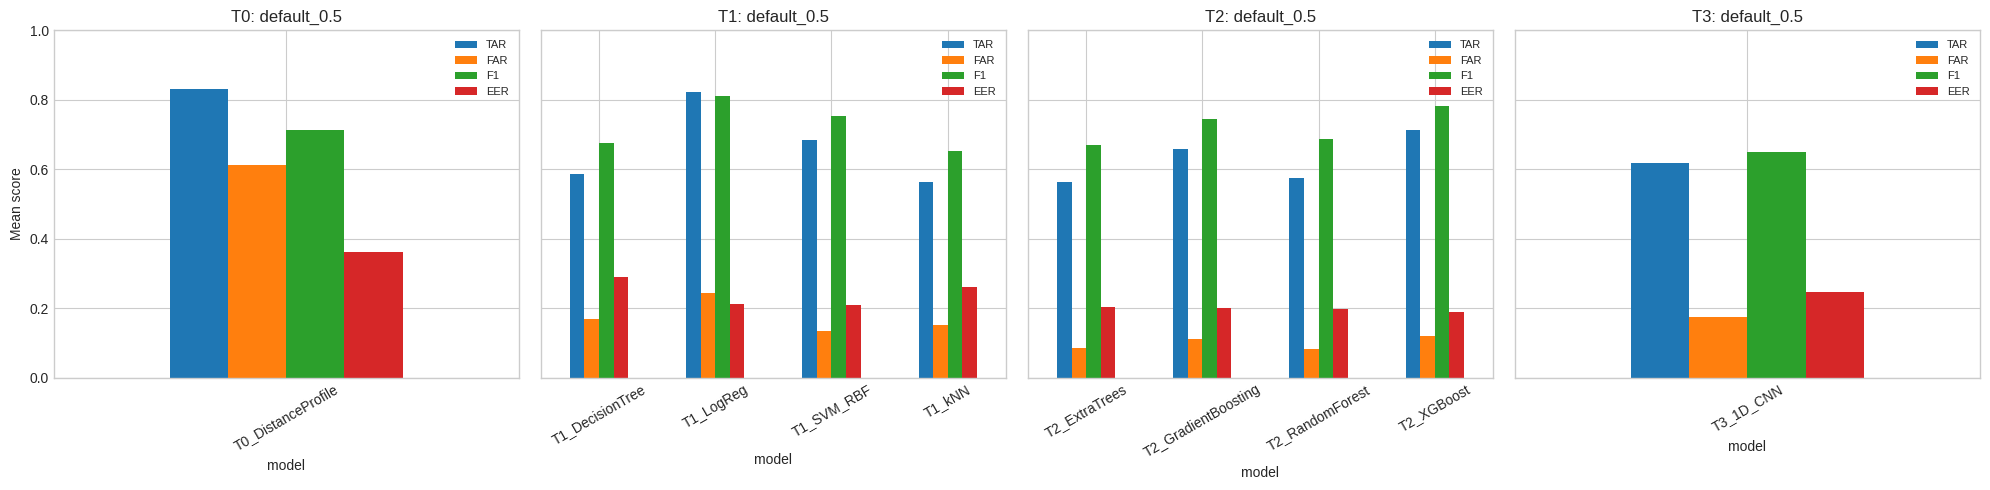

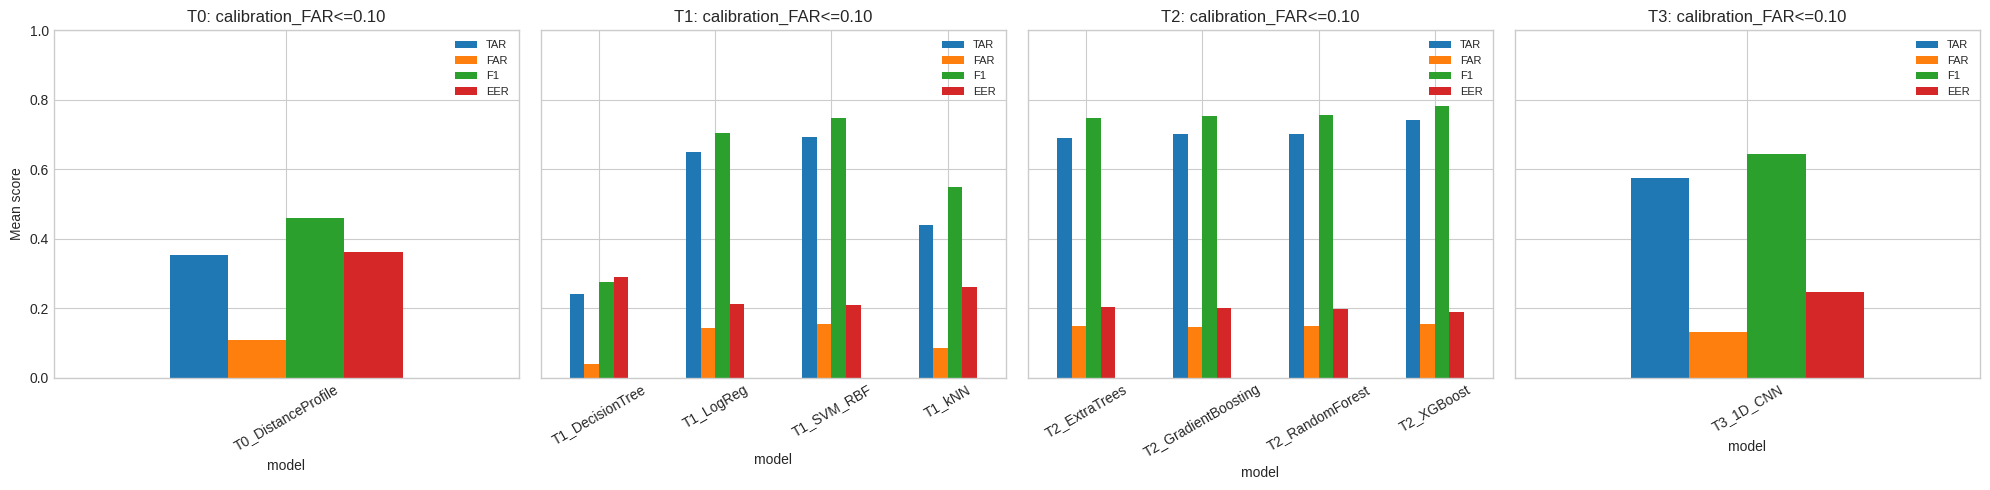

In [41]:
# plot_metric_by_tier(): bar chart comparing tiers on a chosen metric, for a given threshold policy.
plt.style.use("seaborn-v0_8-whitegrid")

def plot_metric_by_tier(policy="default_0.5"):
    plot_df = (
        fair_results[fair_results["threshold_policy"] == policy]
        .groupby(["tier", "model"])[["TAR", "FAR", "F1", "EER"]]
        .mean()
        .reset_index()
    )
    tiers = [t for t in ["T0", "T1", "T2", "T3"] if t in set(plot_df["tier"])]
    fig, axes = plt.subplots(1, len(tiers), figsize=(5 * len(tiers), 5), sharey=True)
    if len(tiers) == 1:
        axes = [axes]
    for ax, tier_name in zip(axes, tiers):
        tier_plot = plot_df[plot_df["tier"] == tier_name].set_index("model")
        tier_plot[["TAR", "FAR", "F1", "EER"]].plot(kind="bar", ax=ax, rot=30)
        ax.set_title(f"{tier_name}: {policy}")
        ax.set_ylim(0, 1)
        ax.set_ylabel("Mean score")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_metric_by_tier("default_0.5")
plot_metric_by_tier(f"calibration_FAR<={LOW_FAR_TARGET:.2f}")


vulnerability_label
medium    34
low       33
high      33
Name: count, dtype: int64


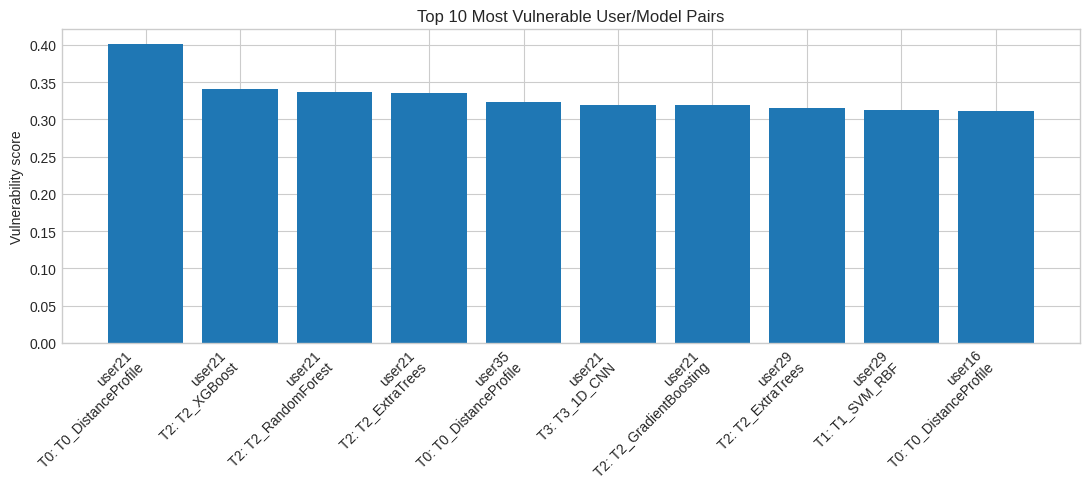

,user,tier,model,FAR,FRR,AUC,EER,vulnerability_score,vulnerability_label
40,user21,T0,T0_DistanceProfile,0.240602,0.775068,0.500448,0.513565,0.400941,high
48,user21,T2,T2_XGBoost,0.413534,0.173442,0.814424,0.277987,0.341506,high
47,user21,T2,T2_RandomForest,0.378446,0.239837,0.782306,0.288419,0.336864,high
45,user21,T2,T2_ExtraTrees,0.370927,0.250678,0.766821,0.301460,0.334852,high
70,user35,T0,T0_DistanceProfile,0.106818,0.826896,0.583906,0.442242,0.322841,high
49,user21,T3,T3_1D_CNN,0.230576,0.527100,0.659117,0.388104,0.319534,high
46,user21,T2,T2_GradientBoosting,0.368421,0.203252,0.808260,0.270060,0.318870,high
65,user29,T2,T2_ExtraTrees,0.333333,0.274278,0.773360,0.309022,0.315617,high
63,user29,T1,T1_SVM_RBF,0.322222,0.288714,0.781097,0.292815,0.312170,high
20,user16,T0,T0_DistanceProfile,0.105866,0.792000,0.589791,0.438169,0.311706,high


In [42]:
vulnerability_policy = f"calibration_FAR<={LOW_FAR_TARGET:.2f}"
vulnerability = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["TAR", "FAR", "FRR", "F1", "AUC", "EER"]]
    .mean()
    .reset_index()
)
vulnerability["vulnerability_score"] = 0.7 * vulnerability["FAR"] + 0.3 * vulnerability["FRR"]

# Low/medium/high labels via tertiles of the observed score distribution.
# Quantile-based (rather than fixed cutoffs like 0.25/0.50) keeps the three
# classes roughly balanced regardless of how spread out the scores are,
# which matters with a small number of user/tier/model rows.
vulnerability["vulnerability_label"] = pd.qcut(
    vulnerability["vulnerability_score"], q=3, labels=["low", "medium", "high"]
)
print(vulnerability["vulnerability_label"].value_counts())

top_vulnerable = vulnerability.sort_values("vulnerability_score", ascending=False).head(10).copy()
top_vulnerable["label"] = top_vulnerable["user"] + "\n" + top_vulnerable["tier"] + ": " + top_vulnerable["model"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_vulnerable["label"], top_vulnerable["vulnerability_score"])
ax.set_title("Top 10 Most Vulnerable User/Model Pairs")
ax.set_ylabel("Vulnerability score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_vulnerable[["user", "tier", "model", "FAR", "FRR", "AUC", "EER", "vulnerability_score", "vulnerability_label"]]


In [43]:
# Builds `vulnerability_features`: clean-side vulnerability scores merged with
# each user/tier/model's calibrated decision_threshold. Reused below by the
# real Vulnerability Classifier v2 (which merges in actual SapiAgent bypass rate).
vuln_lookup = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["decision_threshold"]]
    .mean()
    .reset_index()
)
vulnerability_features = vulnerability.merge(vuln_lookup, on=["user", "tier", "model"], how="left")
vulnerability_features.head()


,user,tier,model,TAR,FAR,FRR,F1,AUC,EER,vulnerability_score,vulnerability_label,decision_threshold
0,user12,T0,T0_DistanceProfile,0.277428,0.126932,0.722572,0.394094,0.636868,0.397837,0.305624,high,0.648430
1,user12,T1,T1_DecisionTree,0.000000,0.000000,1.000000,0.000000,0.650581,0.349419,0.300000,high,1.000000
2,user12,T1,T1_LogReg,0.728861,0.288079,0.271139,0.761907,0.805224,0.272232,0.282997,medium,0.608328
3,user12,T1,T1_SVM_RBF,0.752621,0.293598,0.247379,0.775338,0.806570,0.262171,0.279733,medium,0.439366
4,user12,T1,T1_kNN,0.445842,0.188742,0.554158,0.561696,0.721964,0.325120,0.298367,high,0.733333


/tmp/ipykernel_6874/353719507.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=True)


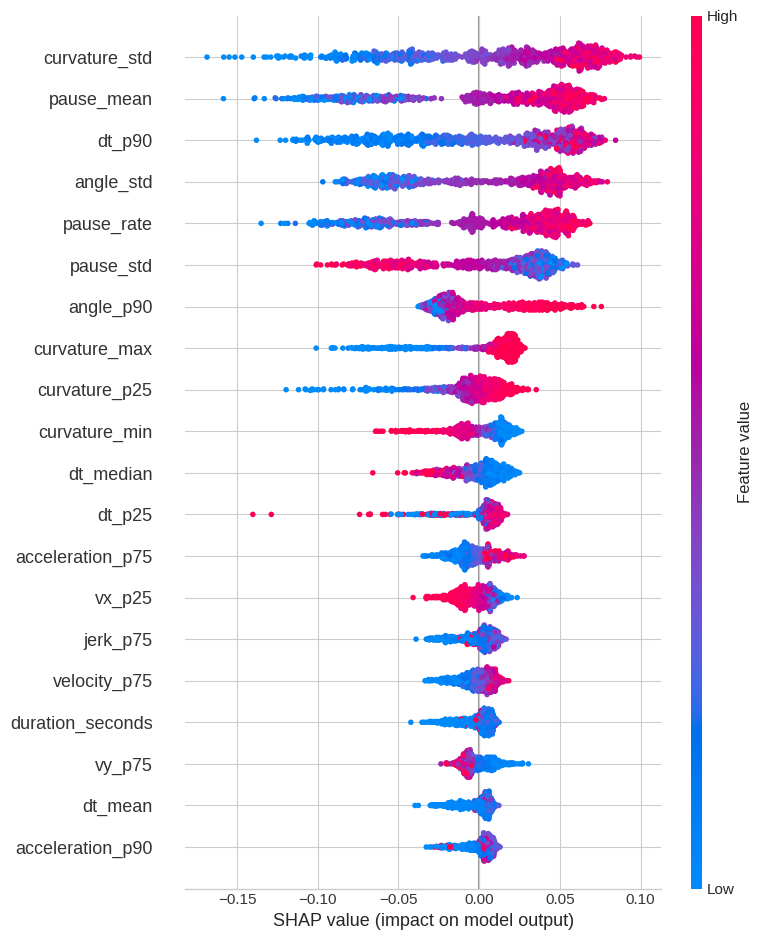

In [44]:
## SHAP Feature Importance (T2 Tree Models)

# !pip install shap --quiet   # uncomment if not already installed in your Colab session

import shap

def run_user_shap(user, seed=0, model_name="T2_RandomForest"):
    splits = get_fair_user_splits(user, seed=seed)
    models = build_t2_models(seed)
    model = models[model_name]
    model.fit(splits["X_fit_tab"], splits["y_fit"])

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(splits["X_test_tab"])

    # Handle both SHAP output formats:
    # - old: list of arrays, one per class -> take class 1 ("genuine")
    # - new: single 3D array (samples, features, classes) -> slice class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    return shap_values, splits["X_test_tab"]

shap_values, X_shap = run_user_shap(example_user, seed=0, model_name="T2_RandomForest")
shap.summary_plot(shap_values, X_shap, show=True)

In [45]:
## Multi-User SHAP Consistency Check

def get_user_shap_importance(user, seed=0, model_name="T2_RandomForest"):
    shap_values, X_shap = run_user_shap(user, seed=seed, model_name=model_name)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    return pd.Series(mean_abs_shap, index=X_shap.columns)

# Start with a handful of users rather than all 10 - SHAP + retraining per user adds up.
# Widen check_users to sorted(user_counts.keys()) later if this looks useful.
check_users = sorted(user_counts.keys())[:5]

importance_by_user = {}
for u in check_users:
    print(f"Computing SHAP importance for {u}...")
    importance_by_user[u] = get_user_shap_importance(u, seed=0)

importance_df = pd.DataFrame(importance_by_user)  # rows = features, columns = users
importance_df["mean_importance"] = importance_df.mean(axis=1)

# rank_std: how much a feature's rank position jumps around between users.
# Low rank_std + high mean_importance = a feature that's reliably important
# everywhere, not just for one user.
ranks = importance_df[check_users].rank(ascending=False)
importance_df["rank_std"] = ranks.std(axis=1)

top_features = importance_df.sort_values("mean_importance", ascending=False).head(15)
top_features[["mean_importance", "rank_std"] + check_users]

Computing SHAP importance for user12...
Computing SHAP importance for user15...
Computing SHAP importance for user16...
Computing SHAP importance for user20...
Computing SHAP importance for user21...


,mean_importance,rank_std,user12,user15,user16,user20,user21
curvature_std,0.031122,16.211107,0.050926,0.078940,0.004411,0.005492,0.015843
dt_p90,0.024880,13.046072,0.047335,0.005598,0.053734,0.011418,0.006314
curvature_p25,0.023631,14.275854,0.015106,0.010873,0.004512,0.004869,0.082796
curvature_p75,0.021413,15.678010,0.004651,0.044157,0.010032,0.004437,0.043788
curvature_p90,0.019145,21.137644,0.005307,0.031537,0.005499,0.002984,0.050398
dt_median,0.018848,4.123106,0.011288,0.018765,0.011790,0.031652,0.020745
acceleration_mean,0.016659,16.364596,0.003505,0.016937,0.018500,0.034793,0.009561
pause_mean,0.016041,27.941009,0.049784,0.002164,0.013890,0.011779,0.002589
angle_std,0.015339,18.873262,0.045045,0.015301,0.005673,0.002991,0.007682
pause_rate,0.015326,28.481573,0.043837,0.002009,0.017058,0.011320,0.002404


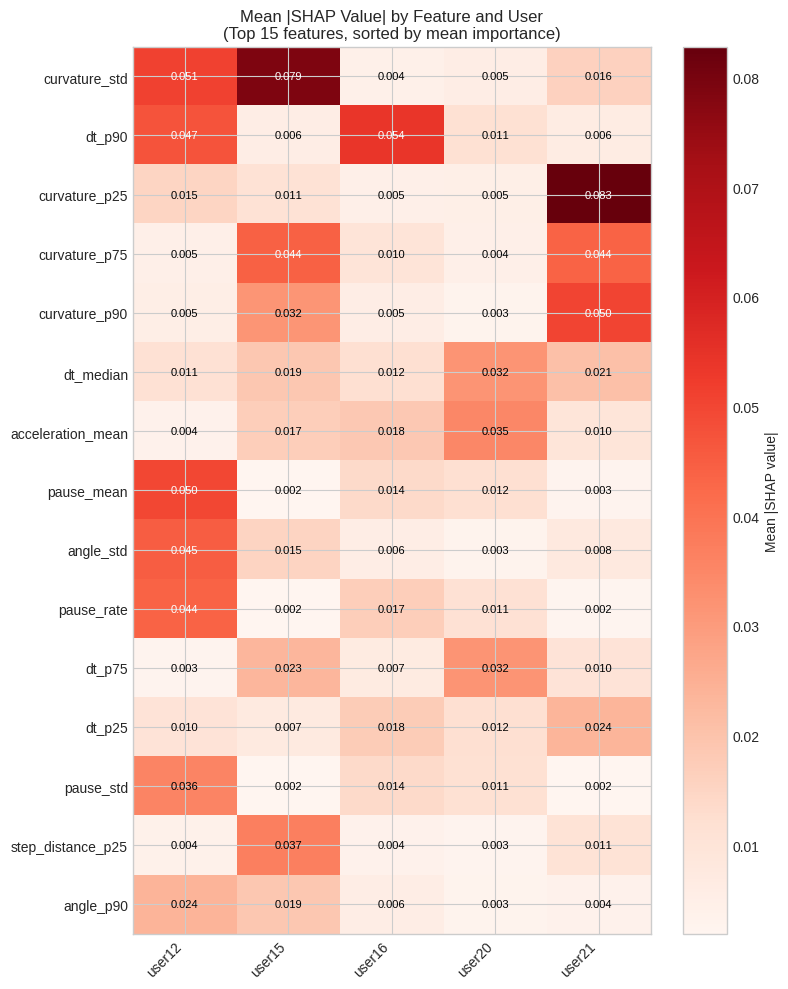

In [46]:
## SHAP Importance Heatmap Across Users

heatmap_data = top_features[check_users]  # reuse the same top 15 features/users from before

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="Reds")

ax.set_xticks(range(len(check_users)))
ax.set_xticklabels(check_users, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index)

# Annotate each cell with its value for readability.
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val > heatmap_data.values.max() * 0.5 else "black",
                fontsize=8)

ax.set_title("Mean |SHAP Value| by Feature and User\n(Top 15 features, sorted by mean importance)")
fig.colorbar(im, ax=ax, label="Mean |SHAP value|")
plt.tight_layout()
plt.show()

# Attacker Scoring Infrastructure

Shared functions used by both WindMouse and SapiAgent below: fits each tier's models per user/seed, calibrates thresholds (including the floor variant), and scores attack sessions against them.

In [53]:
# ================= ALL-TIERS ATTACK BYPASS SCORING (A1 vs A2) =================
# Needs in scope: all_sessions, test_sessions,
# user_counts, get_fair_user_splits, windows_from_sessions, windows_to_tabular,
# threshold_for_target_far, predict_genuine_scores, t0_distance_profile_scores,
# build_t1_models, build_t2_models, build_cnn_fair, and the constants
# (WINDOW, LOW_FAR_TARGET, vulnerability_policy, T3_EPOCHS, T3_VALIDATION_SIZE,
# T3_BATCH_SIZE).
import glob, os
import numpy as np, pandas as pd

ENROLLED_USERS = sorted(user_counts.keys())
ATTACK_SEEDS   = [0, 1, 2]

def load_attack_sessions_by_seed(root, seeds=ATTACK_SEEDS):
    # bare read_csv (already portability-verified); extract_features only needs
    # record timestamp / x / y, which the handoff CSVs have.
    out = {}
    for s in seeds:
        paths = sorted(glob.glob(os.path.join(root, f"seed{s}", "*.csv")))
        out[s] = [pd.read_csv(p) for p in paths]
    return out

def _session_bypassed(win_scores, thr):
    # SESSION RULE (keep identical for BOTH attackers): majority of windows accepted.
    # To use a mean-evidence rule instead, swap for: return win_scores.mean() >= thr
    return float(np.mean(win_scores >= thr)) >= 0.5

def _attack_bypass(score_windows, thr, sessions):
    pooled, sess_flags = [], []
    for sess in sessions:
        Xw, _ = windows_from_sessions([sess], 1)   # per-session windows; label unused
        if len(Xw) == 0:
            continue
        sc = np.asarray(score_windows(Xw), dtype=float)
        pooled.append(sc)
        sess_flags.append(_session_bypassed(sc, thr))
    pooled = np.concatenate(pooled) if pooled else np.array([])
    win_rate  = float(np.mean(pooled >= thr)) if pooled.size else 0.0
    sess_rate = float(np.mean(sess_flags)) if sess_flags else 0.0
    return win_rate, sess_rate

def _tier_scorers(user, seed, t3_epochs):
    # Fit each tier's model(s) on this user's FIT split, calibrate on CAL under
    # BOTH the plain FAR<=0.10 policy and a floored variant (threshold can't
    # drop below THRESHOLD_FLOOR). Returns {(tier, model): (score_windows_fn, {policy_name: threshold})}.
    splits = get_fair_user_splits(user, seed=seed)
    scorers = {}

    def _thresholds(y_cal, cal_scores):
        thr, _, _ = threshold_for_target_far(y_cal, cal_scores, LOW_FAR_TARGET)
        thr_floor = max(thr, THRESHOLD_FLOOR)
        return {
            f"calibration_FAR<={LOW_FAR_TARGET:.2f}": thr,
            f"calibration_FAR<={LOW_FAR_TARGET:.2f}_floor_{THRESHOLD_FLOOR:.2f}": thr_floor,
        }

    # T0 distance profile
    def t0_score(Xw, _s=splits):
        return t0_distance_profile_scores(_s["X_fit_tab"], _s["y_fit"], windows_to_tabular(Xw))
    cal = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    scorers[("T0", "T0_DistanceProfile")] = (t0_score, _thresholds(splits["y_cal"], cal))

    # T1 + T2 tabular sklearn
    for tier, builder in [("T1", build_t1_models), ("T2", build_t2_models)]:
        for name, model in builder(seed).items():
            model.fit(splits["X_fit_tab"], splits["y_fit"])
            cal = predict_genuine_scores(model, splits["X_cal_tab"])
            scorers[(tier, name)] = (
                (lambda Xw, m=model: predict_genuine_scores(m, windows_to_tabular(Xw))),
                _thresholds(splits["y_cal"], cal))

    # T3 1D-CNN on sequences (same train/val split + scaler as run_user_t3_fair)
    np.random.seed(seed); pyrandom.seed(seed); tf.random.set_seed(seed)
    tr_idx, val_idx = grouped_train_validation_indices(
        splits["groups_fit"],
        splits["y_fit"],
        validation_fraction=T3_VALIDATION_SIZE,
        seed=seed,
    )
    f = splits["X_fit_seq"].shape[2]
    scaler = StandardScaler().fit(splits["X_fit_seq"][tr_idx].reshape(-1, f))
    def _scale(seq): return scaler.transform(seq.reshape(-1, f)).reshape(seq.shape)
    cnn = build_cnn_fair(input_shape=(WINDOW, f))
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    cnn.fit(_scale(splits["X_fit_seq"][tr_idx]), splits["y_fit"][tr_idx],
            validation_data=(_scale(splits["X_fit_seq"][val_idx]), splits["y_fit"][val_idx]),
            epochs=t3_epochs, batch_size=T3_BATCH_SIZE, callbacks=[es], verbose=0)
    cal = cnn.predict(_scale(splits["X_cal_seq"]), verbose=0).ravel()
    def t3_score(Xw, _c=cnn, _sc=_scale): return _c.predict(_sc(Xw), verbose=0).ravel()
    scorers[("T3", "T3_1D_CNN")] = (t3_score, _thresholds(splits["y_cal"], cal))
    return scorers

import time

def score_attack_all_tiers(attack_by_seed, attack_type, t3_epochs=T3_EPOCHS,
                           users=ENROLLED_USERS, seeds=ATTACK_SEEDS):
    # Pairs defender(seed) with that seed's attack sessions. One row per
    # (user, tier, model, threshold_policy, seed) - now scored against BOTH
    # the plain FAR<=0.10 threshold and the floored variant, for direct comparison.
    _t0 = time.time()
    rows = []
    for seed in seeds:
        sessions = attack_by_seed[seed]
        for user in users:
            print(f"[{attack_type}] seed={seed} user={user} elapsed={time.time()-_t0:.1f}s")
            for (tier, model_name), (score_fn, thr_dict) in _tier_scorers(user, seed, t3_epochs).items():
                for policy_name, thr in thr_dict.items():
                    wr, sr = _attack_bypass(score_fn, thr, sessions)
                    rows.append({"user": user, "tier": tier, "model": model_name,
                                 "threshold_policy": policy_name, "attack_type": attack_type,
                                 "seed": seed, "accept_threshold": thr,
                                 "bypass_rate_window": wr, "bypass_rate_session": sr})
        print(f"[{attack_type}] seed {seed} done - elapsed={time.time()-_t0:.1f}s")
    print(f"[{attack_type}] fully done in {time.time()-_t0:.1f}s")
    return pd.DataFrame(rows)

## Confidence Intervals for Rates

Per feedback: a 100% rate from a handful of sessions is not equivalent to a 100% rate from hundreds of independent attempts. Every rate reported from here on should go through `rate_with_ci()` so the sample size and uncertainty are visible, not just the point estimate.

In [54]:
def wilson_interval(successes, total, z=1.96):
    """95% Wilson confidence interval for a proportion. More reliable than a normal
    approximation when the count is small or the rate is near 0% or 100%."""
    if total == 0:
        return (np.nan, np.nan)
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))

def rate_with_ci(successes, total):
    """Returns a string like '61.7% (n=60, 95% CI: 48.2-73.9%)' instead of a bare percentage."""
    if total == 0:
        return "n/a (n=0)"
    p = successes / total
    lo, hi = wilson_interval(successes, total)
    return f"{p*100:.1f}% (n={total}, 95% CI: {lo*100:.1f}-{hi*100:.1f}%)"


### WindMouse and SapiAgent scoring - consolidated

The separate WindMouse-only and SapiAgent-only scoring blocks that used to sit here have been removed - they duplicated exactly what the unified A1/A2/A3 section below already does (each one refit T1/T2/T3 per user/seed *again*, on top of the single fit the unified section performs). All WindMouse and SapiAgent results now come from `all_attacks` (built below), which covers the same ground without the redundant retraining.

# Attacker Results: A1 vs. A2 vs. A3 (WindMouse, SapiAgent, Diffusion)

In [55]:
ATTACKS = {}
for name in ["windmouse", "sapiagent", "dmtg"]:
    ATTACKS[name] = load_attack_sessions_by_seed(f"/content/drive/MyDrive/handoff/{name}_sessions")
    print(f"{name}: " + ", ".join(f"seed{s}={len(ATTACKS[name][s])}" for s in ATTACK_SEEDS))

windmouse: seed0=20, seed1=20, seed2=20
sapiagent: seed0=20, seed1=20, seed2=20
dmtg: seed0=20, seed1=20, seed2=20


In [56]:
_sc = _tier_scorers("user9", 0, 2)
fn, thr_dict = _sc[("T1", "T1_SVM_RBF")]
thr = thr_dict["calibration_FAR<=0.10"]
print("threshold:", thr)
for name, by_seed in ATTACKS.items():
    print(f"  {name:10s} (window, session) = {_attack_bypass(fn, thr, by_seed[0])}")

threshold: 0.11163314568587465
  windmouse  (window, session) = (0.008264462809917356, 0.0)
  sapiagent  (window, session) = (0.0, 0.0)
  dmtg       (window, session) = (0.004166666666666667, 0.0)


In [57]:
import time
_t0 = time.time()
rows = []
for seed in ATTACK_SEEDS:
    for user in ENROLLED_USERS:
        print(f"seed={seed} user={user} elapsed={time.time()-_t0:.1f}s")
        scorers = _tier_scorers(user, seed, T3_EPOCHS)          # fit ONCE per (user, seed)
        for name, by_seed in ATTACKS.items():                   # score all three off that fit
            for (tier, model_name), (score_fn, thr_dict) in scorers.items():
                for policy_name, thr in thr_dict.items():
                    wr, sr = _attack_bypass(score_fn, thr, by_seed[seed])
                    rows.append({"user": user, "tier": tier, "model": model_name,
                                 "threshold_policy": policy_name, "attack_type": name,
                                 "seed": seed, "accept_threshold": thr,
                                 "bypass_rate_window": wr, "bypass_rate_session": sr})
    # save after every seed - a disconnect costs a third, not the hour
    pd.DataFrame(rows).to_csv(OUTPUT_DIR / "all_attack_results_corrected.csv", index=False)
    print(f"  seed {seed} saved ({len(rows)} rows) elapsed={time.time()-_t0:.1f}s")

all_attacks = pd.DataFrame(rows)
for name in ATTACKS:
    sub = all_attacks[all_attacks.attack_type == name]
    sub.to_csv(OUTPUT_DIR / f"{name}_all_tiers_corrected.csv", index=False)
    print("saved", name, sub.shape)
print(f"done in {time.time()-_t0:.1f}s | rows {len(all_attacks)}")

seed=0 user=user12 elapsed=0.0s
seed=0 user=user15 elapsed=208.2s
seed=0 user=user16 elapsed=400.3s
seed=0 user=user20 elapsed=596.0s
seed=0 user=user21 elapsed=774.3s
seed=0 user=user23 elapsed=949.1s
seed=0 user=user29 elapsed=1115.4s
seed=0 user=user35 elapsed=1315.7s
seed=0 user=user7 elapsed=1480.8s
seed=0 user=user9 elapsed=1669.5s
  seed 0 saved (600 rows) elapsed=1859.9s
seed=1 user=user12 elapsed=1859.9s
seed=1 user=user15 elapsed=2054.8s
seed=1 user=user16 elapsed=2237.7s
seed=1 user=user20 elapsed=2424.9s
seed=1 user=user21 elapsed=2615.1s
seed=1 user=user23 elapsed=2808.8s
seed=1 user=user29 elapsed=2981.8s
seed=1 user=user35 elapsed=3164.8s
seed=1 user=user7 elapsed=3331.0s
seed=1 user=user9 elapsed=3522.0s
  seed 1 saved (1200 rows) elapsed=3710.9s
seed=2 user=user12 elapsed=3710.9s
seed=2 user=user15 elapsed=3912.9s
seed=2 user=user16 elapsed=4081.6s
seed=2 user=user20 elapsed=4280.1s
seed=2 user=user21 elapsed=4490.5s
seed=2 user=user23 elapsed=4664.0s
seed=2 user=user2

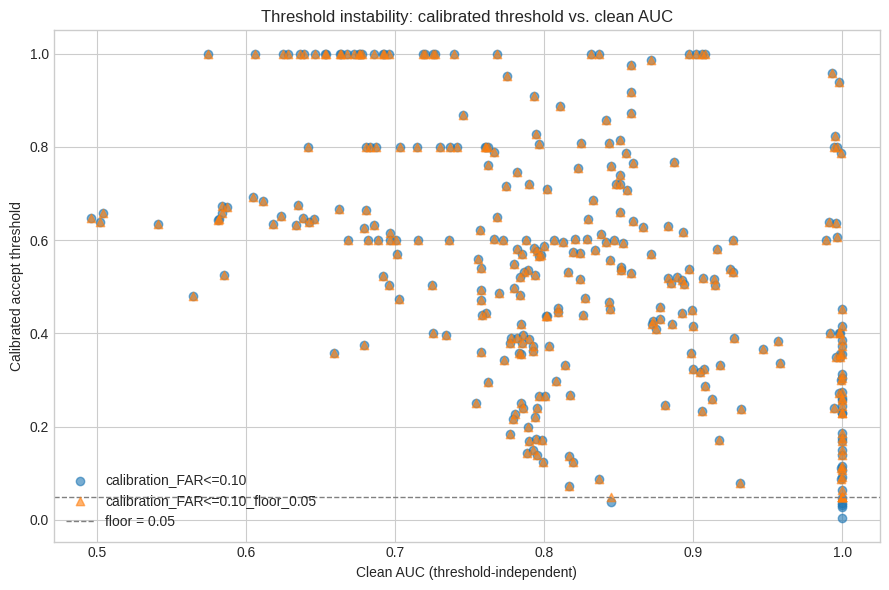

In [58]:
## Threshold Instability: Calibrated Threshold vs. Clean AUC (floor vs. no floor)

import matplotlib.pyplot as plt

# AUC is threshold-independent, so any policy row gives the same AUC per user/tier/model/seed
clean_auc = (
    fair_results[fair_results["threshold_policy"] == "default_0.5"]
    [["user", "tier", "model", "seed", "AUC"]]
)

# accept_threshold doesn't depend on which attacker is being scored (it comes
# purely from calibration data), so any single attacker's rows give the same
# picture - using all_attacks, filtered to one attack_type to avoid triple-counting.
plot_df = (all_attacks[all_attacks["attack_type"] == "sapiagent"]
           .merge(clean_auc, on=["user", "tier", "model", "seed"], how="left"))

fig, ax = plt.subplots(figsize=(9, 6))
for policy, marker in [
    ("calibration_FAR<=0.10", "o"),
    (f"calibration_FAR<=0.10_floor_{THRESHOLD_FLOOR:.2f}", "^"),
]:
    sub = plot_df[plot_df["threshold_policy"] == policy]
    ax.scatter(sub["AUC"], sub["accept_threshold"], label=policy, alpha=0.6, marker=marker)

ax.axhline(THRESHOLD_FLOOR, linestyle="--", linewidth=1, color="gray", label=f"floor = {THRESHOLD_FLOOR}")
ax.set_xlabel("Clean AUC (threshold-independent)")
ax.set_ylabel("Calibrated accept threshold")
ax.set_title("Threshold instability: calibrated threshold vs. clean AUC")
ax.legend()
plt.tight_layout()
plt.show()

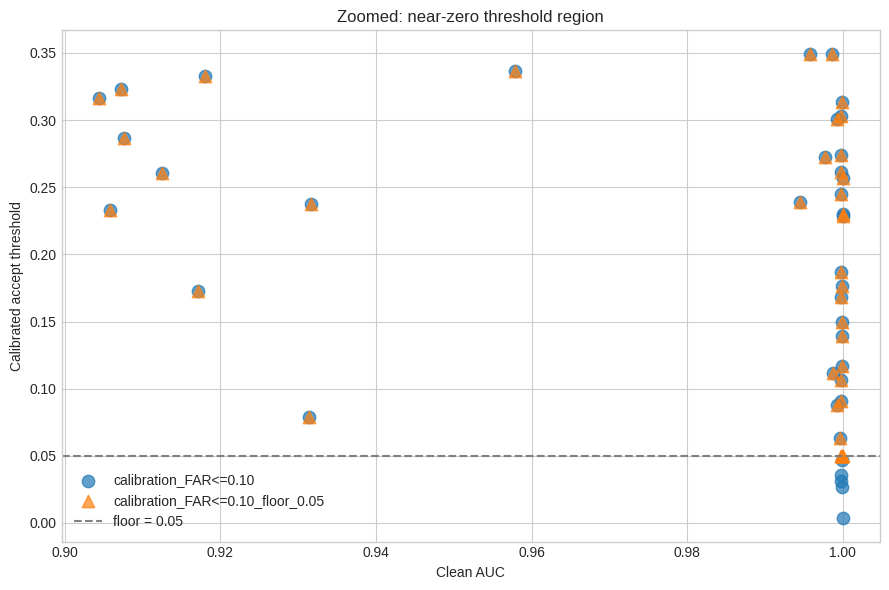

In [59]:
fig, ax = plt.subplots(figsize=(9, 6))
zoom = plot_df[(plot_df["AUC"] > 0.9) & (plot_df["accept_threshold"] < 0.35)]
for policy, marker in [
    ("calibration_FAR<=0.10", "o"),
    (f"calibration_FAR<=0.10_floor_{THRESHOLD_FLOOR:.2f}", "^"),
]:
    sub = zoom[zoom["threshold_policy"] == policy]
    ax.scatter(sub["AUC"], sub["accept_threshold"], label=policy, alpha=0.7, marker=marker, s=80)
ax.axhline(THRESHOLD_FLOOR, linestyle="--", color="gray", label=f"floor = {THRESHOLD_FLOOR}")
ax.set_xlabel("Clean AUC")
ax.set_ylabel("Calibrated accept threshold")
ax.set_title("Zoomed: near-zero threshold region")
ax.legend()
plt.tight_layout()
plt.show()

In [60]:
plot_df[(plot_df["accept_threshold"] < 0.01) & (plot_df["threshold_policy"] == "calibration_FAR<=0.10")][["user", "tier", "model", "seed", "AUC", "accept_threshold"]]

,user,tier,model,seed,AUC,accept_threshold
576,user7,T2,T2_XGBoost,2,0.999982,0.003384


In [61]:
# A0 human-imposter baseline at SESSION level (same majority-vote rule as the attack
# metric), plus genuine session TAR. fair_results reports TAR/FAR at WINDOW level, but
# the headline bypass metric is session-level, so the sanity baseline must match.
# Window-level columns here should reproduce fair_results_stable -> free validation.
import time
_t0 = time.time()
base_rows = []
for seed in ATTACK_SEEDS:
    for user in ENROLLED_USERS:
        print(f"seed={seed} user={user} elapsed={time.time()-_t0:.1f}s")
        scorers  = _tier_scorers(user, seed, T3_EPOCHS)
        gen_test = [s for s in test_sessions if get_user(s) == user and get_label(s) == 0]
        imp_test = [s for s in test_sessions if get_user(s) == user and get_label(s) == 1]
        for (tier, model_name), (score_fn, thr_dict) in scorers.items():
            for policy_name, thr in thr_dict.items():
                gw, gs = _attack_bypass(score_fn, thr, gen_test)
                iw, isx = _attack_bypass(score_fn, thr, imp_test)
                base_rows.append({
                    "user": user, "tier": tier, "model": model_name,
                    "threshold_policy": policy_name, "seed": seed, "accept_threshold": thr,
                    "n_genuine_sessions": len(gen_test), "n_imposter_sessions": len(imp_test),
                    "TAR_window": gw, "TAR_session": gs,
                    "FAR_window": iw, "FAR_session": isx,
                })
    pd.DataFrame(base_rows).to_csv(OUTPUT_DIR / "a0_baseline_session_corrected.csv", index=False)
    print(f"  seed {seed} saved ({len(base_rows)} rows) elapsed={time.time()-_t0:.1f}s")

a0_baseline = pd.DataFrame(base_rows)
print("done:", a0_baseline.shape)

seed=0 user=user12 elapsed=0.0s
seed=0 user=user15 elapsed=263.8s
seed=0 user=user16 elapsed=528.2s
seed=0 user=user20 elapsed=782.3s
seed=0 user=user21 elapsed=917.6s
seed=0 user=user23 elapsed=1074.4s
seed=0 user=user29 elapsed=1236.4s
seed=0 user=user35 elapsed=1414.9s
seed=0 user=user7 elapsed=1629.3s
seed=0 user=user9 elapsed=1820.6s
  seed 0 saved (200 rows) elapsed=1998.4s
seed=1 user=user12 elapsed=1998.4s
seed=1 user=user15 elapsed=2258.0s
seed=1 user=user16 elapsed=2510.4s
seed=1 user=user20 elapsed=2756.5s
seed=1 user=user21 elapsed=2916.4s
seed=1 user=user23 elapsed=3100.8s
seed=1 user=user29 elapsed=3275.3s
seed=1 user=user35 elapsed=3433.7s
seed=1 user=user7 elapsed=3650.7s
seed=1 user=user9 elapsed=3844.9s
  seed 1 saved (400 rows) elapsed=4023.7s
seed=2 user=user12 elapsed=4023.7s
seed=2 user=user15 elapsed=4294.3s
seed=2 user=user16 elapsed=4532.3s
seed=2 user=user20 elapsed=4774.1s
seed=2 user=user21 elapsed=4936.2s
seed=2 user=user23 elapsed=5091.6s
seed=2 user=user2

# Threshold-Floor Sweep

**Feedback:** the threshold-floor correction currently appears motivated primarily by one user/CNN configuration. This section sweeps several floor values across every user, tier, and seed, and reports the effect on bypass rate, FAR, FRR, TAR, and EER - showing whether 0.05 is a generally good choice or just what happened to fix that one case.

Needs `ATTACKS` already loaded (from the A1/A2/A3 section above) - now covers all three attackers, including DMTG, not just WindMouse and SapiAgent.

In [62]:
FLOOR_SWEEP_VALUES = [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]

def _floor_thresholds(y_cal, cal_scores, floors=FLOOR_SWEEP_VALUES):
    base_threshold, _, _ = threshold_for_target_far(
        y_cal,
        cal_scores,
        LOW_FAR_TARGET,
    )
    return {
        floor: max(base_threshold, floor)
        for floor in floors
    }
def run_user_floor_sweep(user, seed, t3_epochs=T3_EPOCHS, attack_session_sets=None):
    """attack_session_sets: dict like {name: by_seed[seed] for name, by_seed in ATTACKS.items()} -
    built fresh per seed in the runner cell below, covers all attackers in ATTACKS (including DMTG).
    Refits each tier ONCE per user/seed (not once per floor) - only the threshold search
    is repeated per floor, so this is not floors-times-slower than a single run."""
    splits = get_fair_user_splits(user, seed=seed)
    rows = []

    def _eval_clean(test_scores, thr):
        y_pred = (test_scores >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(splits["y_test"], y_pred, labels=[0, 1]).ravel()
        tar = tp / (tp + fn) if (tp + fn) else 0.0
        far = fp / (fp + tn) if (fp + tn) else 0.0
        return tar, far, 1 - tar

    def _score_attacks(score_fn, thr):
        out = {}
        if attack_session_sets:
            for atk_name, sessions in attack_session_sets.items():
                if sessions:
                    _, sr = _attack_bypass(score_fn, thr, sessions)
                    out[atk_name] = sr
        return out

    tier_defs = []

    cal0 = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_cal_tab"])
    test0 = t0_distance_profile_scores(splits["X_fit_tab"], splits["y_fit"], splits["X_test_tab"])
    def score0(Xw, _s=splits): return t0_distance_profile_scores(_s["X_fit_tab"], _s["y_fit"], windows_to_tabular(Xw))
    tier_defs.append(("T0", "T0_DistanceProfile", cal0, test0, score0))

    for tier, builder in [("T1", build_t1_models), ("T2", build_t2_models)]:
        for name, model in builder(seed).items():
            model.fit(splits["X_fit_tab"], splits["y_fit"])
            cal = predict_genuine_scores(model, splits["X_cal_tab"])
            test = predict_genuine_scores(model, splits["X_test_tab"])
            def score_fn(Xw, m=model): return predict_genuine_scores(m, windows_to_tabular(Xw))
            tier_defs.append((tier, name, cal, test, score_fn))

    np.random.seed(seed); pyrandom.seed(seed); tf.random.set_seed(seed)
    tr_idx, val_idx = grouped_train_validation_indices(
        splits["groups_fit"],
        splits["y_fit"],
        validation_fraction=T3_VALIDATION_SIZE,
        seed=seed,
    )
    f = splits["X_fit_seq"].shape[2]
    scaler = StandardScaler().fit(splits["X_fit_seq"][tr_idx].reshape(-1, f))
    def _scale(seq): return scaler.transform(seq.reshape(-1, f)).reshape(seq.shape)
    cnn = build_cnn_fair(input_shape=(WINDOW, f))
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    cnn.fit(_scale(splits["X_fit_seq"][tr_idx]), splits["y_fit"][tr_idx],
            validation_data=(_scale(splits["X_fit_seq"][val_idx]), splits["y_fit"][val_idx]),
            epochs=t3_epochs, batch_size=T3_BATCH_SIZE, callbacks=[es], verbose=0)
    cal3 = cnn.predict(_scale(splits["X_cal_seq"]), verbose=0).ravel()
    test3 = cnn.predict(_scale(splits["X_test_seq"]), verbose=0).ravel()
    def score3(Xw, _c=cnn, _sc=_scale): return _c.predict(_sc(Xw), verbose=0).ravel()
    tier_defs.append(("T3", "T3_1D_CNN", cal3, test3, score3))

    for tier, model_name, cal_scores, test_scores, score_fn in tier_defs:
        floor_thr = _floor_thresholds(splits["y_cal"], cal_scores)
        cal_eer, _ = compute_eer_threshold(splits["y_cal"], cal_scores)
        for floor, thr in floor_thr.items():
            tar, far, frr = _eval_clean(test_scores, thr)
            attack_bypass = _score_attacks(score_fn, thr)
            row = {"user": user, "seed": seed, "tier": tier, "model": model_name,
                   "floor": floor, "accept_threshold": thr,
                   "TAR": tar, "FAR": far, "FRR": frr, "EER": cal_eer}
            row.update({f"bypass_{k}": v for k, v in attack_bypass.items()})
            rows.append(row)
    return pd.DataFrame(rows)


In [63]:
# Run the sweep across all users and seeds. This is the slow step (refits T1/T2/T3
# per user/seed, same cost as one full fair_results pass) - run once, save to CSV.
floor_sweep_rows = []
for seed in FAIR_SEEDS:
    # Pulls all three attackers (including DMTG) from ATTACKS.
    attack_sets = {name: by_seed.get(seed, []) for name, by_seed in ATTACKS.items()}
    for user in sorted(user_counts.keys()):
        print(f"floor sweep: seed={seed} user={user}")
        floor_sweep_rows.append(run_user_floor_sweep(user, seed, attack_session_sets=attack_sets))

floor_sweep_results = pd.concat(floor_sweep_rows, ignore_index=True)
floor_sweep_results.to_csv(OUTPUT_DIR / "threshold_floor_sensitivity.csv", index=False)
print("rows:", len(floor_sweep_results))


floor sweep: seed=0 user=user12
floor sweep: seed=0 user=user15
floor sweep: seed=0 user=user16
floor sweep: seed=0 user=user20
floor sweep: seed=0 user=user21
floor sweep: seed=0 user=user23
floor sweep: seed=0 user=user29
floor sweep: seed=0 user=user35
floor sweep: seed=0 user=user7
floor sweep: seed=0 user=user9
floor sweep: seed=1 user=user12
floor sweep: seed=1 user=user15
floor sweep: seed=1 user=user16
floor sweep: seed=1 user=user20
floor sweep: seed=1 user=user21
floor sweep: seed=1 user=user23
floor sweep: seed=1 user=user29
floor sweep: seed=1 user=user35
floor sweep: seed=1 user=user7
floor sweep: seed=1 user=user9
floor sweep: seed=2 user=user12
floor sweep: seed=2 user=user15
floor sweep: seed=2 user=user16
floor sweep: seed=2 user=user20
floor sweep: seed=2 user=user21
floor sweep: seed=2 user=user23
floor sweep: seed=2 user=user29
floor sweep: seed=2 user=user35
floor sweep: seed=2 user=user7
floor sweep: seed=2 user=user9
rows: 2100


In [64]:
# Does the floor generalize, or was 0.05 a one-off? Mean effect per floor value,
# across every user/tier/model/seed - not just the one case that motivated it.
floor_summary = (
    floor_sweep_results
    .groupby("floor")[["TAR", "FAR", "FRR"] + [c for c in floor_sweep_results.columns if c.startswith("bypass_")]]
    .mean()
    .round(4)
)
floor_summary


,TAR,FAR,FRR,bypass_windmouse,bypass_sapiagent,bypass_dmtg
floor,,,,,,
0.00,0.5780,0.1254,0.4220,0.1268,0.1387,0.0585
0.02,0.5780,0.1254,0.4220,0.1268,0.1363,0.0582
0.05,0.5778,0.1253,0.4222,0.1263,0.1345,0.0577
0.08,0.5776,0.1250,0.4224,0.1232,0.1323,0.0577
0.10,0.5773,0.1247,0.4227,0.1228,0.1320,0.0572
0.15,0.5761,0.1234,0.4239,0.1202,0.1268,0.0553
0.20,0.5738,0.1210,0.4262,0.1103,0.1203,0.0485


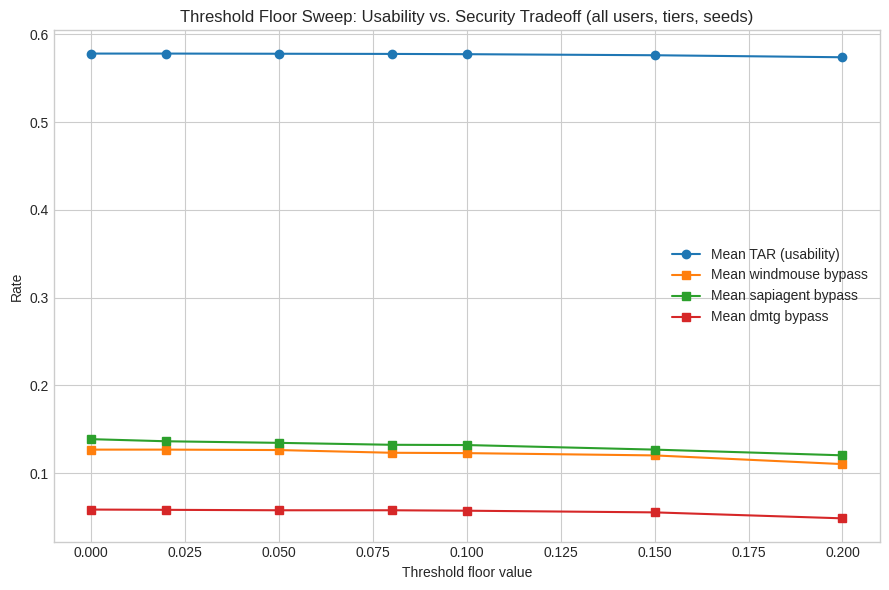

In [65]:
# Usability (TAR) vs. security (bypass rate) tradeoff across floor values.
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(floor_summary.index, floor_summary["TAR"], marker="o", label="Mean TAR (usability)")
for col in [c for c in floor_summary.columns if c.startswith("bypass_")]:
    ax.plot(floor_summary.index, floor_summary[col], marker="s", label=f"Mean {col.replace('bypass_', '')} bypass")
ax.set_xlabel("Threshold floor value")
ax.set_ylabel("Rate")
ax.set_title("Threshold Floor Sweep: Usability vs. Security Tradeoff (all users, tiers, seeds)")
ax.legend()
plt.tight_layout()
plt.show()


# Vulnerability Classifier v2 (Real Bypass Data)

Upgrades the clean-only classifier above with real SapiAgent bypass rate. Binary framing (bypassed at all vs. never) - a 3-class version was tried first but collapsed entirely into one class given how few users show any bypass at all; see writeup/RQ2 for the honest result.

In [66]:
## Vulnerability Classifier v2 (real bypass rate as target)

# Averaged across all three attackers (WindMouse, SapiAgent, DMTG), not just
# SapiAgent - "vulnerability" should mean "vulnerable to attack in general,"
# not "vulnerable to this one specific attacker."
attack_bypass_avg = (
    all_attacks[all_attacks["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["bypass_rate_window", "bypass_rate_session"]]
    .mean()
    .reset_index()
)

vuln_v2 = vulnerability_features.merge(attack_bypass_avg, on=["user", "tier", "model"], how="inner")
print(f"Matched {len(vuln_v2)} of {len(vulnerability_features)} clean-side rows to real bypass data "
      f"(averaged across WindMouse, SapiAgent, and DMTG)")
vuln_v2.head()


Matched 100 of 100 clean-side rows to real bypass data (averaged across WindMouse, SapiAgent, and DMTG)


,user,tier,model,TAR,FAR,FRR,F1,AUC,EER,vulnerability_score,vulnerability_label,decision_threshold,bypass_rate_window,bypass_rate_session
0,user12,T0,T0_DistanceProfile,0.277428,0.126932,0.722572,0.394094,0.636868,0.397837,0.305624,high,0.648430,0.000926,0.000000
1,user12,T1,T1_DecisionTree,0.000000,0.000000,1.000000,0.000000,0.650581,0.349419,0.300000,high,1.000000,0.000000,0.000000
2,user12,T1,T1_LogReg,0.728861,0.288079,0.271139,0.761907,0.805224,0.272232,0.282997,medium,0.608328,0.109169,0.116667
3,user12,T1,T1_SVM_RBF,0.752621,0.293598,0.247379,0.775338,0.806570,0.262171,0.279733,medium,0.439366,0.001389,0.000000
4,user12,T1,T1_kNN,0.445842,0.188742,0.554158,0.561696,0.721964,0.325120,0.298367,high,0.733333,0.118239,0.116667


In [67]:
## Vulnerability classifier: sensitivity to the outcome definition

# "Any bypass at all" depends strongly on the number of attack attempts.
# Evaluate several operational cutoffs rather than presenting one arbitrary
# binary label as definitive.
VULNERABILITY_CUTOFFS = [0.00, 0.05, 0.10, 0.20]
vuln_v2_feature_cols = ["AUC", "FAR", "FRR", "decision_threshold"]

X_vuln2b = vuln_v2[vuln_v2_feature_cols].fillna(0.0)
groups_vuln = vuln_v2["user"].to_numpy()

In [68]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    balanced_accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
)


def evaluate_vulnerability_cutoff(cutoff):
    y_binary = (
        vuln_v2["bypass_rate_session"] > cutoff
    ).astype(int).to_numpy()

    logo = LeaveOneGroupOut()
    true_all, pred_all, score_all = [], [], []

    for train_index, test_index in logo.split(
        X_vuln2b,
        y_binary,
        groups_vuln,
    ):
        model = RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            min_samples_leaf=3,
        )

        y_train = y_binary[train_index]
        if len(np.unique(y_train)) < 2:
            probability = np.full(
                len(test_index),
                y_train.mean(),
                dtype=float,
            )
        else:
            model.fit(
                X_vuln2b.iloc[train_index],
                y_train,
            )
            probability = model.predict_proba(
                X_vuln2b.iloc[test_index]
            )[:, 1]

        prediction = (probability >= 0.5).astype(int)
        true_all.extend(y_binary[test_index])
        pred_all.extend(prediction)
        score_all.extend(probability)

    true_all = np.asarray(true_all)
    pred_all = np.asarray(pred_all)
    score_all = np.asarray(score_all)

    prevalence = float(true_all.mean())
    return {
        "cutoff": cutoff,
        "positive_prevalence": prevalence,
        "balanced_accuracy": balanced_accuracy_score(
            true_all,
            pred_all,
        ),
        "balanced_accuracy_baseline": 0.50,
        "PR_AUC": average_precision_score(
            true_all,
            score_all,
        ),
        "PR_AUC_baseline": prevalence,
        "n_rows": len(true_all),
        "n_users": len(np.unique(groups_vuln)),
    }


vulnerability_sensitivity = pd.DataFrame([
    evaluate_vulnerability_cutoff(cutoff)
    for cutoff in VULNERABILITY_CUTOFFS
])
display(vulnerability_sensitivity)

,cutoff,positive_prevalence,balanced_accuracy,balanced_accuracy_baseline,PR_AUC,PR_AUC_baseline,n_rows,n_users
0,0.00,0.58,0.617406,0.5,0.676295,0.58,100,10
1,0.05,0.45,0.526263,0.5,0.525235,0.45,100,10
2,0.10,0.40,0.554167,0.5,0.510071,0.40,100,10
3,0.20,0.24,0.601974,0.5,0.372428,0.24,100,10


# Save: Vulnerability Classifier Sensitivity

In [69]:
display(vulnerability_sensitivity)

vulnerability_sensitivity.to_csv(
    OUTPUT_DIR / "vulnerability_classifier_sensitivity.csv",
    index=False,
)


,cutoff,positive_prevalence,balanced_accuracy,balanced_accuracy_baseline,PR_AUC,PR_AUC_baseline,n_rows,n_users
0,0.00,0.58,0.617406,0.5,0.676295,0.58,100,10
1,0.05,0.45,0.526263,0.5,0.525235,0.45,100,10
2,0.10,0.40,0.554167,0.5,0.510071,0.40,100,10
3,0.20,0.24,0.601974,0.5,0.372428,0.24,100,10


In [70]:
# Descriptive feature importance only. It is fitted on all rows and therefore
# must not be reported as an independently validated explanation.
SELECTED_VULNERABILITY_CUTOFF = 0.10
selected_label = (
    vuln_v2["bypass_rate_session"] > SELECTED_VULNERABILITY_CUTOFF
).astype(int)

descriptive_vulnerability_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    min_samples_leaf=3,
)
descriptive_vulnerability_model.fit(
    X_vuln2b,
    selected_label,
)

importance_v2b = (
    pd.DataFrame({
        "feature": vuln_v2_feature_cols,
        "descriptive_importance":
            descriptive_vulnerability_model.feature_importances_,
    })
    .sort_values("descriptive_importance", ascending=False)
)
display(importance_v2b)

,feature,descriptive_importance
3,decision_threshold,0.309095
2,FRR,0.256455
1,FAR,0.219239
0,AUC,0.215211


## Vulnerability Classifier - Corrected Evaluation

**Feedback:** the reported confusion matrix (7 bypassed / 23 never-bypassed) means a trivial classifier that always predicts "never bypassed" would score ~77% accuracy - higher than the 73% CV accuracy reported. Plain accuracy makes this look better than it is.

Fixes applied: leave-one-**user**-out CV (rows from the same user aren't independent), balanced accuracy, precision/recall/F1, PR-AUC, and the majority-class baseline reported explicitly alongside the model's real performance.

**Run this cell and share the output so we can write the actual interpretation together** - do not assume the old framing still holds until we see the real balanced accuracy and majority-baseline numbers.

In [71]:
# Paper-facing interpretation for the selected cutoff.
selected_result = vulnerability_sensitivity.loc[
    vulnerability_sensitivity["cutoff"]
    == SELECTED_VULNERABILITY_CUTOFF
].iloc[0]

print(
    f"Leave-one-user-out balanced accuracy: "
    f"{selected_result['balanced_accuracy']:.3f} "
    f"(uninformative baseline = 0.500)"
)
print(
    f"Leave-one-user-out PR-AUC: "
    f"{selected_result['PR_AUC']:.3f} "
    f"(prevalence baseline = "
    f"{selected_result['PR_AUC_baseline']:.3f})"
)
print(
    "Treat this classifier as an exploratory diagnostic. "
    "The effective independent sample size is 10 users."
)

Leave-one-user-out balanced accuracy: 0.554 (uninformative baseline = 0.500)
Leave-one-user-out PR-AUC: 0.510 (prevalence baseline = 0.400)
Treat this classifier as an exploratory diagnostic. The effective independent sample size is 10 users.


# Layered defense: corrected session-level evaluation

The previous anomaly analysis counted windows while labeling them as sessions, used only seed 0, and duplicated genuine/impostor rows once for each attacker. The corrected analysis below:

- uses one complete session as the evaluation unit;
- runs all users and all three seeds;
- includes WindMouse, SapiAgent, and the DMTG-inspired diffusion attacker;
- calibrates the gatekeeper on held-out calibration sessions;
- calibrates the anomaly threshold on held-out genuine sessions;
- reports how many session evaluations reach each stage;
- keeps an optional absolute score floor as sensitivity analysis rather than the default.

In [72]:
from sklearn.ensemble import IsolationForest

LAYERED_GATEKEEPER = "T2_RandomForest"
ANOMALY_FALSE_ALARM_TARGET = 0.05
USE_ABSOLUTE_SCORE_FLOOR = False


def session_feature_row(session):
    features = extract_features(session)[FEATURE_COLS].to_numpy(dtype=float)
    if len(features) == 0:
        return None
    return summarize_window(features)


def session_feature_frame(sessions):
    rows, identifiers = [], []
    for index, session in enumerate(sessions):
        row = session_feature_row(session)
        if row is None:
            continue
        rows.append(row)
        identifiers.append(
            session_identifier(session, fallback=f"session_{index}")
        )
    return pd.DataFrame(rows), identifiers


def gatekeeper_session_score(model, session):
    X_windows, _ = windows_from_sessions([session], label=1)
    if len(X_windows) == 0:
        return np.nan

    window_scores = predict_genuine_scores(
        model,
        windows_to_tabular(X_windows),
    )
    # Mean evidence avoids calling correlated windows independent trials.
    return float(np.mean(window_scores))


def finite_sample_upper_quantile(values, upper_tail_probability):
    values = np.sort(np.asarray(values, dtype=float))
    if len(values) == 0:
        raise ValueError("Cannot calibrate a threshold from an empty array.")

    rank = int(np.ceil((len(values) + 1) * (1 - upper_tail_probability)))
    rank = min(max(rank, 1), len(values))
    return float(values[rank - 1])


def run_user_layered_defense(user, seed, attack_sets):
    splits = get_fair_user_splits(user, seed=seed)

    gatekeeper = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1,
        min_samples_leaf=2,
    )
    gatekeeper.fit(
        splits["X_fit_tab"],
        splits["y_fit"],
    )

    calibration_sessions = (
        splits["cal_genuine_sessions"]
        + splits["cal_imposter_sessions"]
    )
    calibration_labels = np.array(
        [1] * len(splits["cal_genuine_sessions"])
        + [0] * len(splits["cal_imposter_sessions"])
    )
    calibration_scores = np.array([
        gatekeeper_session_score(gatekeeper, session)
        for session in calibration_sessions
    ])

    valid_calibration = np.isfinite(calibration_scores)
    gate_threshold, _, _ = threshold_for_target_far(
        calibration_labels[valid_calibration],
        calibration_scores[valid_calibration],
        target_far=LOW_FAR_TARGET,
    )

    if USE_ABSOLUTE_SCORE_FLOOR:
        gate_threshold = max(gate_threshold, THRESHOLD_FLOOR)

    fit_genuine_frame, _ = session_feature_frame(
        splits["fit_genuine_sessions"]
    )
    calibration_genuine_frame, _ = session_feature_frame(
        splits["cal_genuine_sessions"]
    )

    anomaly_model = make_pipeline(
        StandardScaler(),
        IsolationForest(
            contamination="auto",
            random_state=seed,
            n_estimators=500,
        ),
    )
    anomaly_model.fit(fit_genuine_frame)

    calibration_anomaly_scores = -anomaly_model.decision_function(
        calibration_genuine_frame
    )
    anomaly_threshold = finite_sample_upper_quantile(
        calibration_anomaly_scores,
        upper_tail_probability=ANOMALY_FALSE_ALARM_TARGET,
    )

    source_sessions = {
        "Genuine": splits["test_genuine_sessions"],
        "HumanImpostor": splits["test_imposter_sessions"],
        "WindMouse": attack_sets["windmouse"],
        "SapiAgent": attack_sets["sapiagent"],
        "DMTG_Inspired": attack_sets["dmtg"],
    }

    rows = []
    for source_name, sessions in source_sessions.items():
        session_frame, identifiers = session_feature_frame(sessions)

        for row_index, (session, session_id) in enumerate(
            zip(sessions, identifiers)
        ):
            gate_score = gatekeeper_session_score(
                gatekeeper,
                session,
            )
            if not np.isfinite(gate_score):
                continue

            anomaly_score = float(
                -anomaly_model.decision_function(
                    session_frame.iloc[[row_index]]
                )[0]
            )
            gate_accepted = gate_score >= gate_threshold
            anomaly_flagged = (
                gate_accepted
                and anomaly_score >= anomaly_threshold
            )

            rows.append({
                "user": user,
                "seed": seed,
                "source": source_name,
                "session_id": session_id,
                "gatekeeper": LAYERED_GATEKEEPER,
                "gate_threshold": gate_threshold,
                "gate_score": gate_score,
                "gate_accepted": gate_accepted,
                "anomaly_threshold": anomaly_threshold,
                "anomaly_score": anomaly_score,
                "anomaly_flagged": anomaly_flagged,
                "final_accepted": (
                    gate_accepted and not anomaly_flagged
                ),
            })

    return pd.DataFrame(rows)


layered_rows = []
for seed in FAIR_SEEDS:
    attack_sets = {
        attack_name: ATTACKS[attack_name][seed]
        for attack_name in ["windmouse", "sapiagent", "dmtg"]
    }
    for user in sorted(user_counts.keys()):
        print(f"layered defense: seed={seed}, user={user}")
        layered_rows.append(
            run_user_layered_defense(
                user,
                seed,
                attack_sets,
            )
        )

layered_session_results = pd.concat(
    layered_rows,
    ignore_index=True,
)
layered_session_results.to_csv(
    OUTPUT_DIR / "layered_defense_session_level.csv",
    index=False,
)
print("Session-level evaluation rows:", len(layered_session_results))

layered defense: seed=0, user=user12
layered defense: seed=0, user=user15
layered defense: seed=0, user=user16
layered defense: seed=0, user=user20
layered defense: seed=0, user=user21
layered defense: seed=0, user=user23
layered defense: seed=0, user=user29
layered defense: seed=0, user=user35
layered defense: seed=0, user=user7
layered defense: seed=0, user=user9
layered defense: seed=1, user=user12
layered defense: seed=1, user=user15
layered defense: seed=1, user=user16
layered defense: seed=1, user=user20
layered defense: seed=1, user=user21
layered defense: seed=1, user=user23
layered defense: seed=1, user=user29
layered defense: seed=1, user=user35
layered defense: seed=1, user=user7
layered defense: seed=1, user=user9
layered defense: seed=2, user=user12
layered defense: seed=2, user=user15
layered defense: seed=2, user=user16
layered defense: seed=2, user=user20
layered defense: seed=2, user=user21
layered defense: seed=2, user=user23
layered defense: seed=2, user=user29
layer

In [73]:
def user_cluster_bootstrap(
    frame,
    value_column,
    user_column="user",
    repetitions=5000,
    seed=2026,
):
    user_values = (
        frame.groupby(user_column)[value_column]
        .mean()
        .to_numpy(dtype=float)
    )
    local_rng = np.random.default_rng(seed)
    sampled = local_rng.integers(
        0,
        len(user_values),
        size=(repetitions, len(user_values)),
    )
    bootstrap_means = user_values[sampled].mean(axis=1)
    return {
        "mean": float(user_values.mean()),
        "ci_low": float(np.quantile(bootstrap_means, 0.025)),
        "ci_high": float(np.quantile(bootstrap_means, 0.975)),
        "n_users": len(user_values),
    }


user_source_layered = (
    layered_session_results
    .groupby(["user", "source"], as_index=False)
    .agg(
        n_session_evaluations=("session_id", "size"),
        raw_acceptance=("gate_accepted", "mean"),
        final_acceptance=("final_accepted", "mean"),
        reached_anomaly_layer=("gate_accepted", "sum"),
        anomaly_flags=("anomaly_flagged", "sum"),
    )
)
user_source_layered["detection_among_gate_passers"] = (
    user_source_layered["anomaly_flags"]
    / user_source_layered["reached_anomaly_layer"].replace(0, np.nan)
)

summary_rows = []
for source_name, part in user_source_layered.groupby("source"):
    raw = user_cluster_bootstrap(part, "raw_acceptance")
    final = user_cluster_bootstrap(part, "final_acceptance")
    detection = user_cluster_bootstrap(
        part.dropna(subset=["detection_among_gate_passers"]),
        "detection_among_gate_passers",
    ) if part["detection_among_gate_passers"].notna().any() else {
        "mean": np.nan,
        "ci_low": np.nan,
        "ci_high": np.nan,
        "n_users": 0,
    }

    summary_rows.append({
        "source": source_name,
        "users": raw["n_users"],
        "session_evaluations":
            int(part["n_session_evaluations"].sum()),
        "raw_acceptance_mean": raw["mean"],
        "raw_acceptance_95CI":
            f"{raw['ci_low']:.3f}-{raw['ci_high']:.3f}",
        "final_acceptance_mean": final["mean"],
        "final_acceptance_95CI":
            f"{final['ci_low']:.3f}-{final['ci_high']:.3f}",
        "detection_among_gate_passers_mean": detection["mean"],
        "detection_95CI":
            (
                f"{detection['ci_low']:.3f}-{detection['ci_high']:.3f}"
                if detection["n_users"]
                else "n/a"
            ),
    })

end_to_end_df = pd.DataFrame(summary_rows)
display(end_to_end_df)

,source,users,session_evaluations,raw_acceptance_mean,raw_acceptance_95CI,final_acceptance_mean,final_acceptance_95CI,detection_among_gate_passers_mean,detection_95CI
0,DMTG_Inspired,10,600,0.000000,0.000-0.000,0.000000,0.000-0.000,NaN,n/a
1,Genuine,10,1230,0.536755,0.420-0.644,0.225774,0.118-0.362,0.584340,0.415-0.741
2,HumanImpostor,10,1203,0.036335,0.009-0.070,0.018828,0.001-0.049,0.587302,0.254-0.921
3,SapiAgent,10,600,0.000000,0.000-0.000,0.000000,0.000-0.000,NaN,n/a
4,WindMouse,10,600,0.016667,0.000-0.050,0.000000,0.000-0.000,1.000000,1.000-1.000


In [74]:
# Stage counts are session-model evaluations, not independent people.
stage_breakdown = (
    layered_session_results[
        layered_session_results["source"].isin(
            ["WindMouse", "SapiAgent", "DMTG_Inspired"]
        )
    ]
    .groupby(["user", "source"], as_index=False)
    .agg(
        total_session_evaluations=("session_id", "size"),
        rejected_by_gatekeeper=(
            "gate_accepted",
            lambda values: int((~values).sum()),
        ),
        accepted_and_flagged=(
            "anomaly_flagged",
            "sum",
        ),
        accepted_end_to_end=(
            "final_accepted",
            "sum",
        ),
    )
)
display(
    stage_breakdown.sort_values(
        "accepted_end_to_end",
        ascending=False,
    )
)

,user,source,total_session_evaluations,rejected_by_gatekeeper,accepted_and_flagged,accepted_end_to_end
0,user12,DMTG_Inspired,60,60,0,0
1,user12,SapiAgent,60,60,0,0
2,user12,WindMouse,60,60,0,0
3,user15,DMTG_Inspired,60,60,0,0
4,user15,SapiAgent,60,60,0,0
5,user15,WindMouse,60,60,0,0
6,user16,DMTG_Inspired,60,60,0,0
7,user16,SapiAgent,60,60,0,0
8,user16,WindMouse,60,60,0,0
9,user20,DMTG_Inspired,60,60,0,0


# Robustness Drop (Real SapiAgent Data)

Compares clean FAR against real attack bypass rate - the direct test of whether clean performance predicts attack robustness.

In [75]:
## Robustness Drop (Clean FAR vs. Real SapiAgent Bypass Rate)

clean_far = (
    fair_results[fair_results["threshold_policy"] == vulnerability_policy]
    .groupby(["user", "tier", "model"])[["FAR"]]
    .mean()
    .reset_index()
    .rename(columns={"FAR": "clean_FAR"})
)

# SapiAgent-only view, pulled from all_attacks (filtered) - identical numbers
# to scoring it separately, without the redundant computation.
robustness = (all_attacks[all_attacks["attack_type"] == "sapiagent"]
              .merge(clean_far, on=["user", "tier", "model"], how="left"))
robustness["robustness_drop_window"] = robustness["bypass_rate_window"] - robustness["clean_FAR"]
robustness["robustness_drop_session"] = robustness["bypass_rate_session"] - robustness["clean_FAR"]

robustness.sort_values("robustness_drop_session", ascending=False)[
    ["user", "tier", "model", "threshold_policy", "attack_type",
     "clean_FAR", "bypass_rate_session", "robustness_drop_session"]
].head(15)

,user,tier,model,threshold_policy,attack_type,clean_FAR,bypass_rate_session,robustness_drop_session
565,user7,T1,T1_SVM_RBF,calibration_FAR<=0.10_floor_0.05,sapiagent,0.000000,1.00,1.000000
564,user7,T1,T1_SVM_RBF,calibration_FAR<=0.10,sapiagent,0.000000,1.00,1.000000
162,user7,T1,T1_LogReg,calibration_FAR<=0.10,sapiagent,0.017974,1.00,0.982026
563,user7,T1,T1_LogReg,calibration_FAR<=0.10_floor_0.05,sapiagent,0.017974,1.00,0.982026
362,user7,T1,T1_LogReg,calibration_FAR<=0.10,sapiagent,0.017974,1.00,0.982026
163,user7,T1,T1_LogReg,calibration_FAR<=0.10_floor_0.05,sapiagent,0.017974,1.00,0.982026
562,user7,T1,T1_LogReg,calibration_FAR<=0.10,sapiagent,0.017974,1.00,0.982026
363,user7,T1,T1_LogReg,calibration_FAR<=0.10_floor_0.05,sapiagent,0.017974,1.00,0.982026
86,user21,T1,T1_kNN,calibration_FAR<=0.10,sapiagent,0.117794,1.00,0.882206
286,user21,T1,T1_kNN,calibration_FAR<=0.10,sapiagent,0.117794,1.00,0.882206


In [76]:
# Same robustness-drop ranking as before, now with std across seeds and an
# explicit trial count next to each row.
robustness_with_std = (
    robustness
    .groupby(["user", "tier", "model"])
    .agg(
        clean_FAR=("clean_FAR", "mean"),
        bypass_mean=("bypass_rate_session", "mean"),
        bypass_std=("bypass_rate_session", "std"),
        drop_mean=("robustness_drop_session", "mean"),
        n_trials=("bypass_rate_session", "count"),
    )
    .reset_index()
)
robustness_with_std.sort_values("drop_mean", ascending=False).head(10)


,user,tier,model,clean_FAR,bypass_mean,bypass_std,drop_mean,n_trials
82,user7,T1,T1_LogReg,0.017974,1.000000,0.000000,0.982026,6
72,user35,T1,T1_LogReg,0.126515,1.000000,0.000000,0.873485,6
44,user21,T1,T1_kNN,0.117794,0.983333,0.025820,0.865539,6
42,user21,T1,T1_LogReg,0.300752,1.000000,0.000000,0.699248,6
46,user21,T2,T2_GradientBoosting,0.368421,1.000000,0.000000,0.631579,6
48,user21,T2,T2_XGBoost,0.413534,1.000000,0.000000,0.586466,6
45,user21,T2,T2_ExtraTrees,0.370927,0.900000,0.118322,0.529073,6
74,user35,T1,T1_kNN,0.071212,0.533333,0.434358,0.462121,6
66,user29,T2,T2_GradientBoosting,0.308333,0.666667,0.516398,0.358333,6
65,user29,T2,T2_ExtraTrees,0.333333,0.666667,0.516398,0.333333,6


## Robustness Drop - All Three Attackers

The cell above (`robustness`, `robustness_with_std`) was SapiAgent-only by original design. This version uses `all_attacks` so WindMouse and the diffusion model are included too, not just SapiAgent.

In [77]:
robustness_all = all_attacks.merge(clean_far, on=["user", "tier", "model"], how="left")
robustness_all["robustness_drop_session"] = robustness_all["bypass_rate_session"] - robustness_all["clean_FAR"]

robustness_all_with_std = (
    robustness_all
    .groupby(["user", "tier", "model", "attack_type"])
    .agg(
        clean_FAR=("clean_FAR", "mean"),
        bypass_mean=("bypass_rate_session", "mean"),
        bypass_std=("bypass_rate_session", "std"),
        drop_mean=("robustness_drop_session", "mean"),
        n_trials=("bypass_rate_session", "count"),
    )
    .reset_index()
)
robustness_all_with_std.sort_values("drop_mean", ascending=False).head(15)


,user,tier,model,attack_type,clean_FAR,bypass_mean,bypass_std,drop_mean,n_trials
247,user7,T1,T1_LogReg,sapiagent,0.017974,1.000000,0.000000,0.982026,6
170,user23,T2,T2_GradientBoosting,windmouse,0.080972,1.000000,0.000000,0.919028,6
176,user23,T2,T2_XGBoost,windmouse,0.085020,0.983333,0.025820,0.898313,6
217,user35,T1,T1_LogReg,sapiagent,0.126515,1.000000,0.000000,0.873485,6
133,user21,T1,T1_kNN,sapiagent,0.117794,0.983333,0.025820,0.865539,6
66,user16,T1,T1_LogReg,dmtg,0.127325,0.866667,0.068313,0.739342,6
102,user20,T1,T1_kNN,dmtg,0.016026,0.750000,0.161245,0.733974,6
50,user15,T2,T2_GradientBoosting,windmouse,0.139073,0.850000,0.161245,0.710927,6
38,user15,T1,T1_LogReg,windmouse,0.194996,0.900000,0.154919,0.705004,6
56,user15,T2,T2_XGBoost,windmouse,0.165563,0.866667,0.206559,0.701104,6


# Attacker Comparison: SapiAgent vs. WindMouse (Both All Tiers)

Both attackers now scored with the same infrastructure across all four tiers and both threshold policies, so this is a direct, like-for-like comparison of which attacker is more effective.

In [78]:
# Built from all_attacks (WindMouse + SapiAgent + DMTG diffusion).
tier_comparison = (
    all_attacks
    .groupby(["tier", "attack_type"])[["bypass_rate_window", "bypass_rate_session"]]
    .mean()
    .round(3)
)
tier_comparison


bypass_rate_window  bypass_rate_session
tier attack_type                                         
T0   dmtg                      0.002                0.000
     sapiagent                 0.000                0.000
     windmouse                 0.000                0.000
T1   dmtg                      0.100                0.077
     sapiagent                 0.132                0.128
     windmouse                 0.115                0.097
T2   dmtg                      0.133                0.062
     sapiagent                 0.189                0.179
     windmouse                 0.185                0.177
T3   dmtg                      0.104                0.025
     sapiagent                 0.186                0.137
     windmouse                 0.193                0.171

In [79]:
# Mean +/- std across seeds, not just a bare mean, so a single seed's noise
# isn't mistaken for a real effect.
n_seeds_here = all_attacks["seed"].nunique()
n_users_here = all_attacks["user"].nunique()
print(f"Each cell below aggregates {n_users_here} users x {n_seeds_here} seeds = "
      f"{n_users_here * n_seeds_here} user-by-seed repeated fits; seeds for the same user are not independent participants.")

tier_comparison_with_std = (
    all_attacks
    .groupby(["tier", "attack_type"])[["bypass_rate_window", "bypass_rate_session"]]
    .agg(["mean", "std"])
    .round(3)
)
tier_comparison_with_std


Each cell below aggregates 10 users x 3 seeds = 30 user-by-seed repeated fits; seeds for the same user are not independent participants.


bypass_rate_window        bypass_rate_session       
                               mean    std                mean    std
tier attack_type                                                     
T0   dmtg                     0.002  0.003               0.000  0.000
     sapiagent                0.000  0.000               0.000  0.000
     windmouse                0.000  0.000               0.000  0.000
T1   dmtg                     0.100  0.169               0.077  0.241
     sapiagent                0.132  0.280               0.128  0.324
     windmouse                0.115  0.196               0.097  0.234
T2   dmtg                     0.133  0.142               0.062  0.175
     sapiagent                0.189  0.284               0.179  0.353
     windmouse                0.185  0.273               0.177  0.329
T3   dmtg                     0.104  0.109               0.025  0.072
     sapiagent                0.186  0.230               0.137  0.268
     windmouse                0.193  0.228               0.171  0.305

In [80]:
# Built from all_attacks (all three attackers), showing every pairwise gap
# instead of only sapiagent-vs-windmouse.
user_pivot = (
    all_attacks[all_attacks["threshold_policy"] == "calibration_FAR<=0.10"]
    .groupby(["user", "attack_type"])["bypass_rate_session"]
    .mean()
    .unstack("attack_type")
    .round(3)
)
for a, b in [("sapiagent", "windmouse"), ("dmtg", "sapiagent"), ("dmtg", "windmouse")]:
    if a in user_pivot.columns and b in user_pivot.columns:
        user_pivot[f"gap_{a}_minus_{b}"] = user_pivot[a] - user_pivot[b]

user_pivot.sort_values(
    "gap_sapiagent_minus_windmouse" if "gap_sapiagent_minus_windmouse" in user_pivot.columns else user_pivot.columns[0],
    ascending=False
)


attack_type,dmtg,sapiagent,windmouse,gap_sapiagent_minus_windmouse,gap_dmtg_minus_sapiagent,gap_dmtg_minus_windmouse
user,,,,,,
user21,0.040,0.593,0.000,0.593,-0.553,0.040
user29,0.072,0.282,0.082,0.200,-0.210,-0.010
user35,0.000,0.172,0.002,0.170,-0.172,-0.002
user7,0.037,0.233,0.073,0.160,-0.196,-0.036
user12,0.058,0.008,0.010,-0.002,0.050,0.048
user16,0.093,0.030,0.043,-0.013,0.063,0.050
user20,0.088,0.038,0.057,-0.019,0.050,0.031
user9,0.000,0.002,0.195,-0.193,-0.002,-0.195
user23,0.013,0.027,0.340,-0.313,-0.014,-0.327


In [81]:
# Same per-user comparison, now with std and trial count so a single seed's
# noise can't be mistaken for a real effect.
user_pivot_with_std = (
    all_attacks[all_attacks["threshold_policy"] == "calibration_FAR<=0.10"]
    .groupby(["user", "attack_type"])["bypass_rate_session"]
    .agg(["mean", "std", "count"])
    .round(3)
)
user_pivot_with_std


mean    std  count
user   attack_type                     
user12 dmtg         0.058  0.222     30
       sapiagent    0.008  0.030     30
       windmouse    0.010  0.038     30
user15 dmtg         0.183  0.300     30
       sapiagent    0.002  0.009     30
       windmouse    0.467  0.420     30
user16 dmtg         0.093  0.264     30
       sapiagent    0.030  0.126     30
       windmouse    0.043  0.109     30
user20 dmtg         0.088  0.234     30
       sapiagent    0.038  0.107     30
       windmouse    0.057  0.130     30
user21 dmtg         0.040  0.125     30
       sapiagent    0.593  0.463     30
       windmouse    0.000  0.000     30
user23 dmtg         0.013  0.041     30
       sapiagent    0.027  0.146     30
       windmouse    0.340  0.424     30
user29 dmtg         0.072  0.191     30
       sapiagent    0.282  0.425     30
       windmouse    0.082  0.181     30
user35 dmtg         0.000  0.000     30
       sapiagent    0.172  0.359     30
       windmouse    0.002  0.009     30
user7  dmtg         0.037  0.174     30
       sapiagent    0.233  0.377     30
       windmouse    0.073  0.206     30
user9  dmtg         0.000  0.000     30
       sapiagent    0.002  0.009     30
       windmouse    0.195  0.326     30

# Mechanism analysis: target proximity versus negative-manifold distance

The current notebook demonstrates the paradox but does not yet test its proposed explanation. This section asks whether an attack succeeds when it is:

1. sufficiently close to the target user's genuine behavior; and
2. relatively far from the pooled human-negative distribution used to train rejection.

The analysis uses **whole-session feature vectors**, not individual windows. PCA is used only for visualization. Shrinkage Mahalanobis and k-nearest-neighbor distances provide quantitative measures.

Choose one canonical defender configuration for the main mechanism claim. Do not merge all tiers and models into one dependent sample.

In [82]:
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr

MECHANISM_TIER = "T3"
MECHANISM_MODEL = "T3_1D_CNN"
MECHANISM_POLICY = f"calibration_FAR<={LOW_FAR_TARGET:.2f}"


def session_vectors_with_metadata(
    sessions,
    source,
    seed_value=None,
):
    frame, identifiers = session_feature_frame(sessions)
    frame = frame.copy()
    frame["session_id"] = identifiers
    frame["source"] = source
    frame["attack_seed"] = seed_value
    return frame


def mean_knn_distance(reference, query, neighbors=5):
    k = min(max(1, neighbors), len(reference))
    model = NearestNeighbors(n_neighbors=k).fit(reference)
    distances, _ = model.kneighbors(query)
    return distances.mean(axis=1)


def mahalanobis_distance(values, fitted):
    centered = values - fitted.location_
    return np.sqrt(
        np.einsum(
            "ij,jk,ik->i",
            centered,
            fitted.precision_,
            centered,
        )
    )


mechanism_bypass = (
    all_attacks[
        (all_attacks["tier"] == MECHANISM_TIER)
        & (all_attacks["model"] == MECHANISM_MODEL)
        & (all_attacks["threshold_policy"] == MECHANISM_POLICY)
    ]
    .groupby(["user", "attack_type"], as_index=False)
    .agg(
        bypass_rate=("bypass_rate_session", "mean"),
        seed_variation=("bypass_rate_session", "std"),
    )
)

mechanism_rows = []
mechanism_cache = {}

for target_user in sorted(user_counts.keys()):
    target_sessions = [
        session for session in all_sessions
        if get_user(session) == target_user
    ]
    pooled_negative_sessions = [
        session for session in all_sessions
        if get_user(session) != target_user
    ]

    target_frame = session_vectors_with_metadata(
        target_sessions,
        "TargetGenuine",
    )
    negative_frame = session_vectors_with_metadata(
        pooled_negative_sessions,
        "PooledHumanNegative",
    )

    attack_frames = []
    for attack_name in ["windmouse", "sapiagent", "dmtg"]:
        for attack_seed in FAIR_SEEDS:
            attack_frames.append(
                session_vectors_with_metadata(
                    ATTACKS[attack_name][attack_seed],
                    attack_name,
                    attack_seed,
                )
            )
    attack_frame = pd.concat(attack_frames, ignore_index=True)

    metadata_columns = {
        "session_id",
        "source",
        "attack_seed",
    }
    vector_columns = [
        column for column in target_frame.columns
        if column not in metadata_columns
    ]

    scaler = StandardScaler().fit(
        pd.concat(
            [
                target_frame[vector_columns],
                negative_frame[vector_columns],
            ],
            ignore_index=True,
        )
    )

    target_values = scaler.transform(
        target_frame[vector_columns]
    )
    negative_values = scaler.transform(
        negative_frame[vector_columns]
    )
    attack_values = scaler.transform(
        attack_frame[vector_columns]
    )

    target_covariance = LedoitWolf().fit(target_values)
    negative_covariance = LedoitWolf().fit(negative_values)

    attack_frame = attack_frame.copy()
    attack_frame["distance_to_target_knn"] = mean_knn_distance(
        target_values,
        attack_values,
    )
    attack_frame["distance_to_negative_knn"] = mean_knn_distance(
        negative_values,
        attack_values,
    )
    attack_frame["distance_to_target_mahal"] = mahalanobis_distance(
        attack_values,
        target_covariance,
    )
    attack_frame["distance_to_negative_mahal"] = mahalanobis_distance(
        attack_values,
        negative_covariance,
    )
    attack_frame["blind_spot_margin_knn"] = (
        attack_frame["distance_to_negative_knn"]
        - attack_frame["distance_to_target_knn"]
    )

    mechanism_cache[target_user] = {
        "target_frame": target_frame,
        "negative_frame": negative_frame,
        "attack_frame": attack_frame,
        "vector_columns": vector_columns,
        "target_values": target_values,
        "negative_values": negative_values,
        "attack_values": attack_values,
    }

    for attack_name, part in attack_frame.groupby("source"):
        mechanism_rows.append({
            "user": target_user,
            "attack_type": attack_name,
            "n_attack_sessions": len(part),
            "distance_to_target_knn":
                part["distance_to_target_knn"].median(),
            "distance_to_negative_knn":
                part["distance_to_negative_knn"].median(),
            "distance_to_target_mahal":
                part["distance_to_target_mahal"].median(),
            "distance_to_negative_mahal":
                part["distance_to_negative_mahal"].median(),
            "blind_spot_margin_knn":
                part["blind_spot_margin_knn"].median(),
        })

mechanism_summary = (
    pd.DataFrame(mechanism_rows)
    .merge(
        mechanism_bypass,
        on=["user", "attack_type"],
        how="left",
    )
)
display(mechanism_summary.head(12))

,user,attack_type,n_attack_sessions,distance_to_target_knn,distance_to_negative_knn,distance_to_target_mahal,distance_to_negative_mahal,blind_spot_margin_knn,bypass_rate,seed_variation
0,user12,dmtg,60,314.771532,313.865127,1947.753081,457.524044,-1.501350,0.000000,0.000000
1,user12,sapiagent,60,115.837718,112.450109,681.611512,188.446907,-3.249439,0.066667,0.076376
2,user12,windmouse,60,1344.269163,1344.228559,8319.867971,1956.364582,-0.098570,0.000000,0.000000
3,user15,dmtg,60,314.781675,313.865127,1199.111116,475.412123,-1.393081,0.116667,0.160728
4,user15,sapiagent,60,117.927716,112.450109,417.857938,198.891000,-5.363694,0.000000,0.000000
5,user15,windmouse,60,1344.250460,1344.228848,5122.310878,2037.367441,-0.062424,0.533333,0.419325
6,user16,dmtg,60,314.748234,313.865127,1326.049801,462.403287,-0.938712,0.000000,0.000000
7,user16,sapiagent,60,116.391514,112.450109,471.998229,187.965228,-3.858870,0.216667,0.375278
8,user16,windmouse,60,1344.259133,1344.228559,5663.928042,1976.718839,-0.084065,0.000000,0.000000
9,user20,dmtg,60,313.941621,314.671397,248.356016,1174.328216,-0.048983,0.083333,0.144338


# Save: Mechanism Analysis Summary

In [83]:
display(mechanism_summary.head())

mechanism_summary.to_csv(
    OUTPUT_DIR / "mechanism_user_attacker_summary.csv",
    index=False,
)


,user,attack_type,n_attack_sessions,distance_to_target_knn,distance_to_negative_knn,distance_to_target_mahal,distance_to_negative_mahal,blind_spot_margin_knn,bypass_rate,seed_variation
0,user12,dmtg,60,314.771532,313.865127,1947.753081,457.524044,-1.501350,0.000000,0.000000
1,user12,sapiagent,60,115.837718,112.450109,681.611512,188.446907,-3.249439,0.066667,0.076376
2,user12,windmouse,60,1344.269163,1344.228559,8319.867971,1956.364582,-0.098570,0.000000,0.000000
3,user15,dmtg,60,314.781675,313.865127,1199.111116,475.412123,-1.393081,0.116667,0.160728
4,user15,sapiagent,60,117.927716,112.450109,417.857938,198.891000,-5.363694,0.000000,0.000000


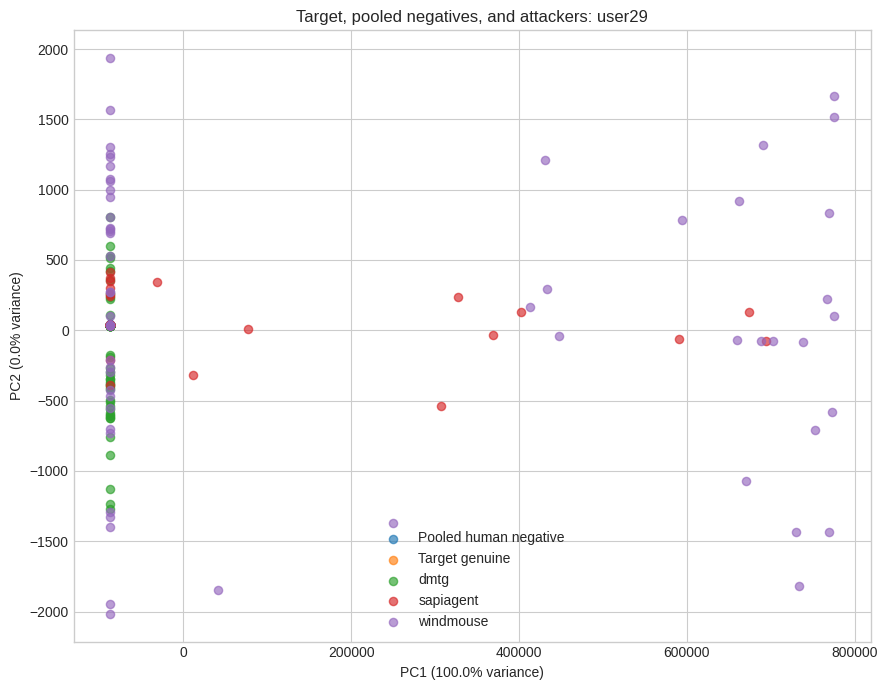

In [84]:
# Representative PCA figure. Select the user with the largest attacker-specific
# spread in bypass rate under the canonical defender.
representative_user = (
    mechanism_summary.groupby("user")["bypass_rate"]
    .agg(lambda values: values.max() - values.min())
    .sort_values(ascending=False)
    .index[0]
)

cache = mechanism_cache[representative_user]
negative_limit = min(200, len(cache["negative_values"]))
negative_indices = np.random.default_rng(2026).choice(
    len(cache["negative_values"]),
    size=negative_limit,
    replace=False,
)

combined_values = np.vstack([
    cache["target_values"],
    cache["negative_values"][negative_indices],
    cache["attack_values"],
])
combined_labels = (
    ["Target genuine"] * len(cache["target_values"])
    + ["Pooled human negative"] * negative_limit
    + cache["attack_frame"]["source"].tolist()
)

pca = PCA(n_components=2, random_state=2026)
coordinates = pca.fit_transform(combined_values)

pca_frame = pd.DataFrame({
    "PC1": coordinates[:, 0],
    "PC2": coordinates[:, 1],
    "source": combined_labels,
})

plt.figure(figsize=(9, 7))
for source_name, part in pca_frame.groupby("source"):
    plt.scatter(
        part["PC1"],
        part["PC2"],
        label=source_name,
        alpha=0.65,
        s=35,
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)"
)
plt.title(
    f"Target, pooled negatives, and attackers: {representative_user}"
)
plt.legend()
plt.tight_layout()
plt.show()

,predictor,spearman_rho,user_block_permutation_p,n_users
0,distance_to_target_knn,-0.036864,0.829034,10
1,distance_to_negative_knn,0.179846,0.329734,10
2,blind_spot_margin_knn,0.294200,0.096981,10


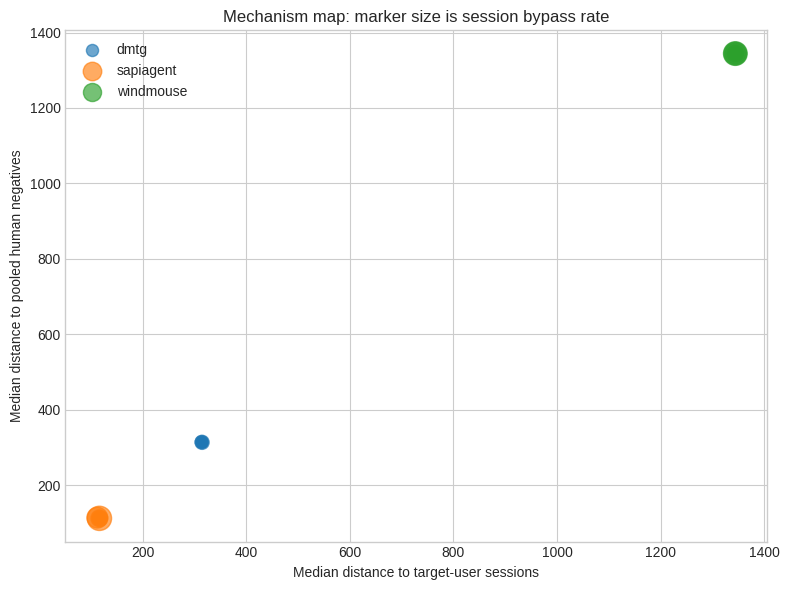

In [85]:
def user_block_permutation_correlation(
    frame,
    predictor,
    outcome,
    repetitions=5000,
    seed=2026,
):
    local = frame.dropna(
        subset=[predictor, outcome]
    ).reset_index(drop=True)

    observed = spearmanr(
        local[predictor],
        local[outcome],
    ).statistic

    group_indices = [
        np.asarray(indices)
        for indices in local.groupby("user").groups.values()
    ]
    original_outcome = local[outcome].to_numpy()
    local_rng = np.random.default_rng(seed)
    null_values = np.empty(repetitions)

    for repetition in range(repetitions):
        permuted = original_outcome.copy()
        for indices in group_indices:
            permuted[indices] = local_rng.permutation(
                permuted[indices]
            )
        null_values[repetition] = spearmanr(
            local[predictor],
            permuted,
        ).statistic

    p_value = (
        1 + np.sum(np.abs(null_values) >= abs(observed))
    ) / (repetitions + 1)
    return observed, p_value


mechanism_tests = []
for predictor in [
    "distance_to_target_knn",
    "distance_to_negative_knn",
    "blind_spot_margin_knn",
]:
    rho, p_value = user_block_permutation_correlation(
        mechanism_summary,
        predictor,
        "bypass_rate",
    )
    mechanism_tests.append({
        "predictor": predictor,
        "spearman_rho": rho,
        "user_block_permutation_p": p_value,
        "n_users": mechanism_summary["user"].nunique(),
    })

display(pd.DataFrame(mechanism_tests))

plt.figure(figsize=(8, 6))
for attack_name, part in mechanism_summary.groupby("attack_type"):
    marker_sizes = 50 + 450 * part["bypass_rate"].fillna(0)
    plt.scatter(
        part["distance_to_target_knn"],
        part["distance_to_negative_knn"],
        s=marker_sizes,
        alpha=0.65,
        label=attack_name,
    )

plt.xlabel("Median distance to target-user sessions")
plt.ylabel("Median distance to pooled human negatives")
plt.title("Mechanism map: marker size is session bypass rate")
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
def paired_user_permutation(
    frame,
    attack_a,
    attack_b,
    repetitions=5000,
    seed=2026,
):
    wide = (
        frame[
            frame["attack_type"].isin([attack_a, attack_b])
        ]
        .pivot_table(
            index="user",
            columns="attack_type",
            values="bypass_rate",
            aggfunc="mean",
        )
        .dropna()
    )
    difference = (
        wide[attack_a] - wide[attack_b]
    ).to_numpy(dtype=float)
    observed = float(difference.mean())

    local_rng = np.random.default_rng(seed)
    signs = local_rng.choice(
        [-1.0, 1.0],
        size=(repetitions, len(difference)),
    )
    null_values = (signs * difference).mean(axis=1)
    p_value = (
        1 + np.sum(np.abs(null_values) >= abs(observed))
    ) / (repetitions + 1)

    return {
        "comparison": f"{attack_a} - {attack_b}",
        "mean_user_level_difference": observed,
        "paired_permutation_p": p_value,
        "n_users": len(difference),
    }


paired_attacker_tests = pd.DataFrame([
    paired_user_permutation(
        mechanism_summary,
        "windmouse",
        "sapiagent",
    ),
    paired_user_permutation(
        mechanism_summary,
        "windmouse",
        "dmtg",
    ),
    paired_user_permutation(
        mechanism_summary,
        "sapiagent",
        "dmtg",
    ),
])
display(paired_attacker_tests)

,comparison,mean_user_level_difference,paired_permutation_p,n_users
0,windmouse - sapiagent,0.033333,0.772246,10
1,windmouse - dmtg,0.145000,0.036393,10
2,sapiagent - dmtg,0.111667,0.143571,10


# Failure Case Analysis

**Feedback #9:** use SHAP and representative cases to explore *why* certain users and models are vulnerable - for models with low clean FAR but high bypass, users vulnerable mainly to one attacker, and sessions caught at each stage of defense.

**Important caveat, stated explicitly per the feedback:** SHAP shows association, not causation. This section develops hypotheses about which behavioral features matter for specific vulnerable cases - it does not prove that those features *cause* the vulnerability. Treat these as leads for further testing (e.g., targeted ablations), not as final explanations.

In [87]:
# Pull out one concrete representative case for each failure pattern.

worst_robustness = robustness_all_with_std.sort_values("drop_mean", ascending=False).iloc[0]

most_windmouse_vulnerable_user = user_pivot.sort_values("gap_sapiagent_minus_windmouse").index[0]
most_sapiagent_vulnerable_user = user_pivot.sort_values("gap_sapiagent_minus_windmouse", ascending=False).index[0]
most_dmtg_vulnerable_user = user_pivot.sort_values("gap_dmtg_minus_sapiagent", ascending=False).index[0]

representative_cases = pd.DataFrame([
    {
        "case": "Low clean FAR, high bypass",
        "user": worst_robustness["user"], "tier": worst_robustness["tier"], "model": worst_robustness["model"],
        "attack_type": worst_robustness["attack_type"],
        "clean_FAR": f"{worst_robustness['clean_FAR']:.3f}",
        "bypass_rate": f"{worst_robustness['bypass_mean']:.3f} (+/- {worst_robustness['bypass_std']:.3f}, n={worst_robustness['n_trials']})",
    },
    {
        "case": "Vulnerable mainly to WindMouse",
        "user": most_windmouse_vulnerable_user, "tier": "-", "model": "-", "clean_FAR": "-",
        "bypass_rate": f"WindMouse={user_pivot.loc[most_windmouse_vulnerable_user].get('windmouse', float('nan')):.3f}, "
                       f"SapiAgent={user_pivot.loc[most_windmouse_vulnerable_user].get('sapiagent', float('nan')):.3f}, "
                       f"DMTG={user_pivot.loc[most_windmouse_vulnerable_user].get('dmtg', float('nan')):.3f}",
    },
    {
        "case": "Vulnerable mainly to SapiAgent",
        "user": most_sapiagent_vulnerable_user, "tier": "-", "model": "-", "clean_FAR": "-",
        "bypass_rate": f"WindMouse={user_pivot.loc[most_sapiagent_vulnerable_user].get('windmouse', float('nan')):.3f}, "
                       f"SapiAgent={user_pivot.loc[most_sapiagent_vulnerable_user].get('sapiagent', float('nan')):.3f}, "
                       f"DMTG={user_pivot.loc[most_sapiagent_vulnerable_user].get('dmtg', float('nan')):.3f}",
    },
    {
        "case": "Vulnerable mainly to DMTG",
        "user": most_dmtg_vulnerable_user, "tier": "-", "model": "-", "clean_FAR": "-",
        "bypass_rate": f"WindMouse={user_pivot.loc[most_dmtg_vulnerable_user].get('windmouse', float('nan')):.3f}, "
                       f"SapiAgent={user_pivot.loc[most_dmtg_vulnerable_user].get('sapiagent', float('nan')):.3f}, "
                       f"DMTG={user_pivot.loc[most_dmtg_vulnerable_user].get('dmtg', float('nan')):.3f}",
    },
])
representative_cases

,case,user,tier,model,attack_type,clean_FAR,bypass_rate
0,"Low clean FAR, high bypass",user7,T1,T1_LogReg,sapiagent,0.018,"1.000 (+/- 0.000, n=6)"
1,Vulnerable mainly to WindMouse,user15,-,-,NaN,-,"WindMouse=0.467, SapiAgent=0.002, DMTG=0.183"
2,Vulnerable mainly to SapiAgent,user21,-,-,NaN,-,"WindMouse=0.000, SapiAgent=0.593, DMTG=0.040"
3,Vulnerable mainly to DMTG,user15,-,-,NaN,-,"WindMouse=0.467, SapiAgent=0.002, DMTG=0.183"


In [88]:
# Hypothesis-level comparison (not causal): do users vulnerable to different
# attackers rely on visibly different behavioral features?
windmouse_vuln_importance = get_user_shap_importance(most_windmouse_vulnerable_user, seed=0)
sapiagent_vuln_importance = get_user_shap_importance(most_sapiagent_vulnerable_user, seed=0)
dmtg_vuln_importance = get_user_shap_importance(most_dmtg_vulnerable_user, seed=0)

shap_case_comparison = pd.DataFrame({
    f"{most_windmouse_vulnerable_user} (WindMouse-vulnerable)": windmouse_vuln_importance,
    f"{most_sapiagent_vulnerable_user} (SapiAgent-vulnerable)": sapiagent_vuln_importance,
    f"{most_dmtg_vulnerable_user} (DMTG-vulnerable)": dmtg_vuln_importance,
}).sort_values(f"{most_windmouse_vulnerable_user} (WindMouse-vulnerable)", ascending=False)

shap_case_comparison.head(10)

,user15 (WindMouse-vulnerable),user21 (SapiAgent-vulnerable),user15 (DMTG-vulnerable)
curvature_std,0.078940,0.015843,0.078940
curvature_p75,0.044157,0.043788,0.044157
step_distance_p25,0.036934,0.010574,0.036934
curvature_p90,0.031537,0.050398,0.031537
curvature_max,0.024998,0.001509,0.024998
dt_p75,0.023144,0.010237,0.023144
dt_min,0.022425,0.005632,0.022425
dt_median,0.018765,0.020745,0.018765
angle_p90,0.018655,0.003690,0.018655
acceleration_mean,0.016937,0.009561,0.016937


In [89]:
# Corrected stage breakdown using complete sessions and all three attackers.
stage_breakdown = (
    layered_session_results[
        layered_session_results["source"].isin(
            ["WindMouse", "SapiAgent", "DMTG_Inspired"]
        )
    ]
    .groupby(["user", "source"], as_index=False)
    .agg(
        total_session_evaluations=("session_id", "size"),
        rejected_by_gatekeeper=(
            "gate_accepted",
            lambda values: int((~values).sum()),
        ),
        accepted_and_flagged=("anomaly_flagged", "sum"),
        accepted_end_to_end=("final_accepted", "sum"),
    )
)
display(
    stage_breakdown.sort_values(
        "accepted_end_to_end",
        ascending=False,
    ).head(15)
)

,user,source,total_session_evaluations,rejected_by_gatekeeper,accepted_and_flagged,accepted_end_to_end
0,user12,DMTG_Inspired,60,60,0,0
1,user12,SapiAgent,60,60,0,0
2,user12,WindMouse,60,60,0,0
3,user15,DMTG_Inspired,60,60,0,0
4,user15,SapiAgent,60,60,0,0
5,user15,WindMouse,60,60,0,0
6,user16,DMTG_Inspired,60,60,0,0
7,user16,SapiAgent,60,60,0,0
8,user16,WindMouse,60,60,0,0
9,user20,DMTG_Inspired,60,60,0,0


## Aggregate vs. Per-User Framing

**Feedback:** the presentation currently states "WindMouse wins at every tier" while the per-user table shows SapiAgent winning for some users - both are true, but need to be stated precisely rather than left ambiguous:

> **WindMouse has the higher *aggregate* bypass rate at every defender tier, but attacker effectiveness varies considerably by individual user.** This user-specific variation is one of the project's more important findings, not a contradiction of the tier-level result.

## Provisional summary after the methodological corrections

### RQ1 — Can mouse movement verify enrolled users?
The notebook includes T0–T3 defenders under a common protocol, but all clean-performance numbers must be regenerated after complete-session splitting and corrected timestamp processing. The most defensible comparison is the distribution of user-level performance, not only the mean across windows.

### RQ2 — How vulnerable are the defenders to synthetic impersonation?
The existing results show substantial attacker- and user-specific variation. WindMouse has the highest aggregate bypass in the original run, but the ranking is not universal at the user level. The revised mechanism section tests whether this pattern is associated with target proximity and distance from pooled human negatives.

### RQ3 — Does a layered defense reduce successful bypass?
The revised anomaly evaluation uses complete sessions, all three seeds, and all three attacks. Report raw session bypass, the number of sessions reaching the anomaly layer, detection among those sessions, final end-to-end bypass, and genuine-session false alarms together.

### Main paper-facing conclusion
Clean authentication performance is not sufficient evidence of robustness under active impersonation. However, claims about *why* a less human-like attacker succeeds should remain conditional until the new feature-space and distance analyses support the proposed blind-spot mechanism.

# Documentation for Paper / README

**Feedback #2 and #3 (write-up items):** report the full dataset/protocol description and explicitly justify the baseline choices. The cell below prints the real numbers from this run so the paper/README can be filled in with actual facts rather than estimates.

In [90]:
# Prints the real numbers behind the experimental protocol, pulled directly from this
# run rather than estimated. Copy these into the paper's Methods / README.
print("=== Dataset ===")
print(f"Users: {len(user_counts)}  ->  {sorted(user_counts.keys())}")
print(f"Total training sessions loaded: {len(all_sessions)}")
print(f"Total test sessions loaded: {len(test_sessions)}")
print(f"Window size: {WINDOW} time steps")
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print()
print("=== Fair evaluation protocol ===")
print(f"Seeds used: {FAIR_SEEDS}  (n={len(FAIR_SEEDS)} repeated trials per user/model)")
print(f"Threshold policies: default_0.5, calibration_EER, calibration_FAR<={LOW_FAR_TARGET:.2f}, "
      f"calibration_FAR<={LOW_FAR_TARGET:.2f}_floor_{THRESHOLD_FLOOR:.2f}")
print()
# Pulls session counts from ATTACKS (all three attackers, including DMTG).
print("=== Attacker sessions (attack budget) ===")
n_seeds_used = len(FAIR_SEEDS)
n_users_tested = len(user_counts)
for name, by_seed in ATTACKS.items():
    per_seed = len(by_seed[0])
    total_sessions = per_seed * n_seeds_used
    total_attempts = total_sessions * n_users_tested
    print(f"{name}: {per_seed} sessions/seed x {n_seeds_used} seeds = {total_sessions} unique attack sessions")
    print(f"      scored against {n_users_tested} users defenses -> {total_attempts} total attack attempts")
print()
print("=== T3 (CNN) parameters ===")
print(f"Epochs: {T3_EPOCHS}  |  Validation size: {T3_VALIDATION_SIZE}  |  Batch size: {T3_BATCH_SIZE}")


=== Dataset ===
Users: 10  ->  ['user12', 'user15', 'user16', 'user20', 'user21', 'user23', 'user29', 'user35', 'user7', 'user9']
Total training sessions loaded: 65
Total test sessions loaded: 816
Window size: 128 time steps
Feature columns (10): ['dt', 'step_distance', 'vx', 'vy', 'velocity', 'acceleration', 'jerk', 'angle', 'curvature', 'pause']

=== Fair evaluation protocol ===
Seeds used: [0, 1, 2]  (n=3 repeated trials per user/model)
Threshold policies: default_0.5, calibration_EER, calibration_FAR<=0.10, calibration_FAR<=0.10_floor_0.05

=== Attacker sessions (attack budget) ===
windmouse: 20 sessions/seed x 3 seeds = 60 unique attack sessions
      scored against 10 users defenses -> 600 total attack attempts
sapiagent: 20 sessions/seed x 3 seeds = 60 unique attack sessions
      scored against 10 users defenses -> 600 total attack attempts
dmtg: 20 sessions/seed x 3 seeds = 60 unique attack sessions
      scored against 10 users defenses -> 600 total attack attempts

=== T3 (C

### Baseline justification (fill in for the paper)

Why each tier was selected as a baseline - state this explicitly in the paper rather than leaving it implicit:

- **T0 (distance-to-profile):** the simplest possible sanity baseline - establishes the floor of what "no real modeling" achieves, so any added complexity in T1-T3 can be justified against it.
- **T1 (Logistic Regression, SVM, k-NN, Decision Tree):** standard, well-understood classical ML baselines widely used in prior mouse-dynamics authentication work; cheap to train and calibrate per user.
- **T2 (Random Forest, ExtraTrees, Gradient Boosting, XGBoost):** stronger tabular ensembles, representing the practical ceiling for feature-engineered approaches without deep learning.
- **T3 (1D-CNN):** represents a raw-sequence deep learning approach, testing whether learned representations outperform engineered features - directly relevant since prior work disagrees on this point for behavioral biometrics.

*(Adjust the wording above if your actual reasoning differs - these are drafted from the project's design, not asserted facts.)*

## Demo export — bypass-animation inputs (additive)

Exports two small CSVs for a demo animation **without re-running any canonical
scoring cell**. Target: **user9, seed 0, T2_RandomForest**, policy
`calibration_FAR<=0.10`. Fits only a T2 Random Forest (no T3/CNN) and reuses the
cell-74 IsolationForest layered-defense setup at the **session** level.

- **`demo_scores_user9.csv`** — one row per session:
  `source, session_id, score, threshold, accepted, anomaly_flagged, window_threshold, max_window_score`.
  `score` = fraction of the session's windows scoring ≥ the T2 window threshold;
  `threshold` = 0.5 (majority rule); `accepted` = `score >= 0.5`;
  `anomaly_flagged` = session-level IsolationForest verdict; `window_threshold`
  and `max_window_score` are reference columns.
- **`demo_trajectories_user9.csv`** — the highest-scoring window per session,
  128 rows (`step` 0–127) of raw `x, y`, taken from the same
  `collapse_duplicate_timestamps` frame the features come from.

Prereq: run the notebook top-to-bottom through cell 52 (`ATTACKS`) and cell 74
(anomaly helpers) so the referenced functions are in scope.


In [ ]:
# =====================================================================
# DEMO EXPORT (additive) — two small CSVs for a bypass demo animation.
# Target: user9, seed 0, T2_RandomForest, policy calibration_FAR<=0.10.
#
# ADDITIVE and self-contained: fits ONLY a T2 Random Forest (no T3/CNN) and
# writes only demo_* files. It does NOT modify or re-run any canonical
# *_corrected.csv cell. Prereqs: run the notebook top-to-bottom through
# cell 52 (ATTACKS) and cell 74 (session-level anomaly helpers).
# =====================================================================
from sklearn.ensemble import IsolationForest  # (already imported in cell 74)

DEMO_USER, DEMO_SEED = "user9", 0
DEMO_POLICY = f"calibration_FAR<={LOW_FAR_TARGET:.2f}"
MAJORITY = 0.5

_splits = get_fair_user_splits(DEMO_USER, seed=DEMO_SEED)

# --- trimmed scorer: fit ONLY T2_RandomForest; take its FAR<=0.10 window threshold
_rf = build_t2_models(DEMO_SEED)["T2_RandomForest"]
_rf.fit(_splits["X_fit_tab"], _splits["y_fit"])
_cal = predict_genuine_scores(_rf, _splits["X_cal_tab"])
WINDOW_THRESHOLD, _cal_far, _cal_tar = threshold_for_target_far(
    _splits["y_cal"], _cal, LOW_FAR_TARGET)  # do not recalibrate elsewhere

# --- session-level anomaly model, reusing the cell-74 layered-defense setup ---
_fit_gen, _ = session_feature_frame(_splits["fit_genuine_sessions"])
_cal_gen, _ = session_feature_frame(_splits["cal_genuine_sessions"])
_anomaly = make_pipeline(
    StandardScaler(),
    IsolationForest(contamination="auto", random_state=DEMO_SEED, n_estimators=500),
)
_anomaly.fit(_fit_gen)
_anom_thr = finite_sample_upper_quantile(
    -_anomaly.decision_function(_cal_gen), ANOMALY_FALSE_ALARM_TARGET)


def _demo_score_session(sess):
    Xw, _ = windows_from_sessions([sess], 1)
    if len(Xw) == 0:
        return None
    tab = windows_to_tabular(Xw)
    sc = np.asarray(predict_genuine_scores(_rf, tab), dtype=float)
    best = int(np.argmax(sc))                       # window drawn in the animation
    frac = float(np.mean(sc >= WINDOW_THRESHOLD))   # session bypass fraction
    sframe, _ = session_feature_frame([sess])       # session-level anomaly (cell 74)
    anom = float(-_anomaly.decision_function(sframe)[0]) if len(sframe) else np.nan
    return {"score": frac, "max_window_score": float(sc[best]),
            "accepted": bool(frac >= MAJORITY),
            "anomaly_flagged": bool(np.isfinite(anom) and anom >= _anom_thr),
            "best": best}


def _demo_select(sessions, ids, n=8, need_accepted=False):
    scored = [(sid, s, _demo_score_session(s)) for s, sid in zip(sessions, ids)]
    scored = [t for t in scored if t[2] is not None]
    chosen = list(range(min(n, len(scored))))
    if need_accepted and not any(scored[i][2]["accepted"] for i in chosen):
        acc = [i for i, t in enumerate(scored) if t[2]["accepted"]]
        if acc:                                     # sample more until one passes
            chosen = sorted(set(chosen[:n - 1] + [acc[0]]))
    return [scored[i] for i in chosen]


# genuine = user9 held-out TEST genuine split; attackers = ATTACKS[name][seed 0]
_gen = _splits["test_genuine_sessions"]
_gen_ids = [session_identifier(s) for s in _gen]
_wm, _dm = ATTACKS["windmouse"][DEMO_SEED], ATTACKS["dmtg"][DEMO_SEED]
_wm_ids = [f"windmouse_s{i:02d}" for i in range(len(_wm))]
_dm_ids = [f"dmtg_s{i:02d}" for i in range(len(_dm))]

_selected = (
    [("genuine", t) for t in _demo_select(_gen, _gen_ids, 8, need_accepted=True)]
    + [("windmouse", t) for t in _demo_select(_wm, _wm_ids, 8, need_accepted=True)]
    + [("dmtg", t) for t in _demo_select(_dm, _dm_ids, 8, need_accepted=False)]
)

_score_rows, _traj_rows = [], []
for source, (sid, sess, r) in _selected:
    _score_rows.append({
        "source": source, "session_id": sid,
        "score": r["score"], "threshold": MAJORITY, "accepted": r["accepted"],
        "anomaly_flagged": r["anomaly_flagged"],
        "window_threshold": WINDOW_THRESHOLD, "max_window_score": r["max_window_score"],
    })
    core = collapse_duplicate_timestamps(sess).reset_index(drop=True)
    start = r["best"] * WINDOW
    for step, (_, rr) in enumerate(core.iloc[start:start + WINDOW].iterrows()):
        _traj_rows.append({"source": source, "session_id": sid,
                           "step": step, "x": rr["x"], "y": rr["y"]})

demo_scores = pd.DataFrame(_score_rows)
demo_trajectories = pd.DataFrame(_traj_rows)
demo_scores.to_csv(OUTPUT_DIR / "demo_scores_user9.csv", index=False)
demo_trajectories.to_csv(OUTPUT_DIR / "demo_trajectories_user9.csv", index=False)

# --- report ---
def _acc(s): return int(((demo_scores.source == s) & demo_scores.accepted).sum())
def _tot(s): return int((demo_scores.source == s).sum())
def _flag(s): return int(((demo_scores.source == s) & demo_scores.anomaly_flagged).sum())

print("FEATURE_COLS (%d): %s" % (len(FEATURE_COLS), FEATURE_COLS))
print("window threshold (T2_RandomForest, %s): %.6f  [cal FAR %.3f, TAR %.3f]"
      % (DEMO_POLICY, WINDOW_THRESHOLD, _cal_far, _cal_tar))
print("session rule: accepted = (fraction of windows >= %.3f) >= %.1f"
      % (WINDOW_THRESHOLD, MAJORITY))
print("session-level anomaly threshold (IsolationForest, FAR<=%.2f): %.6f"
      % (ANOMALY_FALSE_ALARM_TARGET, _anom_thr))
for s in ["genuine", "windmouse", "dmtg"]:
    print("  %-10s accepted %d/%d   anomaly_flagged %d/%d"
          % (s, _acc(s), _tot(s), _flag(s), _tot(s)))
print("SANITY  genuine>=1 accepted: %s | DMTG all rejected: %s | WindMouse>=1 accepted: %s"
      % (_acc("genuine") >= 1, _acc("dmtg") == 0, _acc("windmouse") >= 1))
print("wrote %s (%d rows)" % (OUTPUT_DIR / "demo_scores_user9.csv", len(demo_scores)))
print("wrote %s (%d rows)" % (OUTPUT_DIR / "demo_trajectories_user9.csv", len(demo_trajectories)))
display(demo_scores)